# TellCo - User Analytics in the Telecommunication Industry
Complete project: Task 1 (Overview), Task 2 (Engagement), Task 3 (Experience),
Task 4 (Satisfaction + SQL Server export + model tracking).

How to run: open this notebook in Jupyter / VS Code, keep telcom_data__2_.xlsx in the same
folder and click 'Run All'. All charts are already shown inside this file and are also saved in ./charts.

## 0. Setup & configuration

In [1]:
import os, sys, json, time, hashlib, warnings, datetime as dt
from urllib.parse import quote_plus

import numpy as np
import pandas as pd
import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")            # plain `python file.py` -> only save charts
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 12, "axes.titleweight": "bold"})

# ---- paths (change if your files are elsewhere) ----
DATA_FILE = os.environ.get("DATA_FILE", "telcom_data__2_.xlsx")
CHART_DIR = "charts"
OUT_DIR = "outputs"
os.makedirs(CHART_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

# ---- SQL Server settings (your local instance) ----
SQL_SERVER = r".\SQLEXPRESS"
SQL_DATABASE = "telecom_db"
SQL_TABLE = "user_satisfaction"
SQL_DRIVER = "ODBC Driver 17 for SQL Server"

RANDOM_STATE = 42
CHART_LOG = []                       # used by the notebook builder


def save_show(name):
    """Save the current figure to charts/<name>.png and show it in notebooks."""
    path = os.path.join(CHART_DIR, f"{name}.png")
    plt.tight_layout()
    plt.savefig(path, dpi=110, bbox_inches="tight")
    CHART_LOG.append(path)
    if "ipykernel" in sys.modules:
        plt.show()
    plt.close()


def fmt_bytes(x):
    for unit in ["B", "KB", "MB", "GB", "TB"]:
        if abs(x) < 1024:
            return f"{x:,.1f} {unit}"
        x /= 1024
    return f"{x:,.1f} PB"

## 1. Load data & reusable cleaning helpers

In [2]:
raw = pd.read_excel(DATA_FILE)
raw = raw.dropna(how="all")
raw = raw.dropna(subset=["Start"])               # last row of the file is a blank record
raw.columns = [c.strip() for c in raw.columns]
print("Raw shape:", raw.shape)
raw.head()

Raw shape: (150000, 55)


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,...,Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,...,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,...,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,...,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,...,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,...,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [3]:
# Column groups
APPS = ["Social Media", "Google", "Email", "Youtube", "Netflix", "Gaming", "Other"]
for a in APPS:
    raw[f"{a} Total (Bytes)"] = raw[f"{a} DL (Bytes)"] + raw[f"{a} UL (Bytes)"]
raw["Total Data (Bytes)"] = raw["Total DL (Bytes)"] + raw["Total UL (Bytes)"]
APP_TOTAL_COLS = [f"{a} Total (Bytes)" for a in APPS]

# Data-quality check: do the 7 app volumes add up to Total DL+UL?
_ratio = raw[APP_TOTAL_COLS].sum(axis=1) / raw["Total Data (Bytes)"]
print(f"Sum of app volumes / Total DL+UL: median {_ratio.median():.2f}x, "
      f"{(_ratio > 1).mean() * 100:.1f}% of sessions have apps > total  (data inconsistency!)")

# Handsets labelled 'undefined' are really unknown -> treat as missing
for c in ["Handset Manufacturer", "Handset Type"]:
    raw[c] = raw[c].replace("undefined", np.nan)


def treat_missing(df, num_cols, cat_cols=()):
    """Numeric NaN -> column mean, categorical NaN -> column mode."""
    df = df.copy()
    for c in num_cols:
        df[c] = df[c].fillna(df[c].mean())
    for c in cat_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].mode().iloc[0])
    return df


def treat_outliers(df, cols, k=3.0):
    """Values outside [Q1-k*IQR, Q3+k*IQR] are replaced with the column mean
    (mean is computed on the non-outlier values). k=3 flags only extreme values."""
    df = df.copy()
    report = {}
    for c in cols:
        df[c] = df[c].astype(float)
        q1, q3 = df[c].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - k * iqr, q3 + k * iqr
        mask = (df[c] < lo) | (df[c] > hi)
        report[c] = int(mask.sum())
        if mask.any():
            df.loc[mask, c] = df.loc[~mask, c].mean()
    return df, pd.Series(report, name="outliers_replaced")

Sum of app volumes / Total DL+UL: median 1.85x, 100.0% of sessions have apps > total  (data inconsistency!)


## 2. Data quality overview (missing values & dtypes)

                                                   dtype  missing  missing_%  unique
Bearer Id                                         object        0       0.00  134709
Start                                     datetime64[us]        0       0.00  111881
Start ms                                         float64        0       0.00    1000
End                                       datetime64[us]        0       0.00  100962
End ms                                           float64        0       0.00    1000
Dur. (ms)                                        float64        0       0.00   89525
IMSI                                             float64      569       0.38  107265
MSISDN/Number                                    float64     1065       0.71  106856
IMEI                                             float64      571       0.38  107270
Last Location Name                                object     1152       0.77   45547
Avg RTT DL (ms)                                  float64    27828

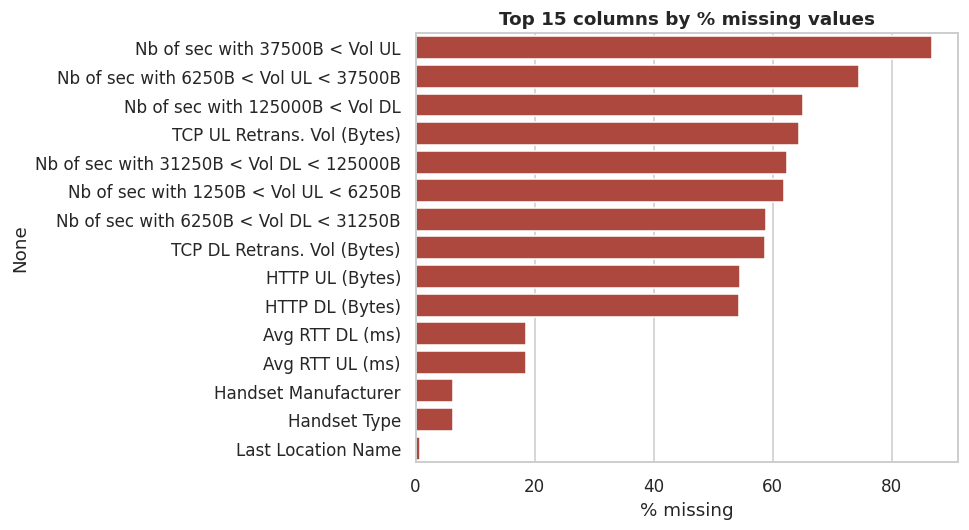

In [4]:
dq = pd.DataFrame({"dtype": raw.dtypes.astype(str),
                   "missing": raw.isna().sum(),
                   "missing_%": (raw.isna().mean() * 100).round(2),
                   "unique": raw.nunique()})
print(dq.to_string())
dq.to_csv(f"{OUT_DIR}/data_quality.csv")

top_missing = dq.sort_values("missing_%", ascending=False).head(15)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_missing["missing_%"], y=top_missing.index, color="#c0392b")
plt.title("Top 15 columns by % missing values"); plt.xlabel("% missing")
save_show("00_missing_values")

# TASK 1 - USER OVERVIEW ANALYSIS

### 1.0 Top handsets & manufacturers

TOP 10 HANDSETS
 Handset Type
Huawei B528S-23A                19752
Apple iPhone 6S (A1688)          9419
Apple iPhone 6 (A1586)           9023
Apple iPhone 7 (A1778)           6326
Apple iPhone Se (A1723)          5187
Apple iPhone 8 (A1905)           4993
Apple iPhone Xr (A2105)          4568
Samsung Galaxy S8 (Sm-G950F)     4520
Apple iPhone X (A1901)           3813
Samsung Galaxy A5 Sm-A520F       3724
Name: count, dtype: int64 

TOP 3 MANUFACTURERS
 Handset Manufacturer
Apple      59565
Samsung    40839
Huawei     34423
Name: count, dtype: int64 

Top 5 handsets - Apple
Handset Type
Apple iPhone 6S (A1688)    9419
Apple iPhone 6 (A1586)     9023
Apple iPhone 7 (A1778)     6326
Apple iPhone Se (A1723)    5187
Apple iPhone 8 (A1905)     4993
Name: count, dtype: int64

Top 5 handsets - Samsung
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4520
Samsung Galaxy A5 Sm-A520F      3724
Samsung Galaxy J5 (Sm-J530)     3696
Samsung Galaxy J3 (Sm-J330)     3484
Samsung Galaxy S7 (Sm-G930X)    

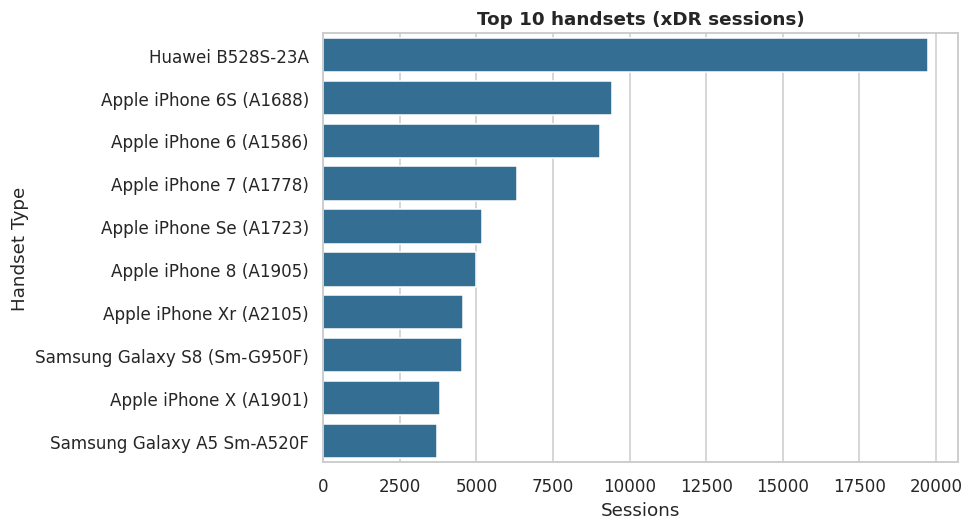

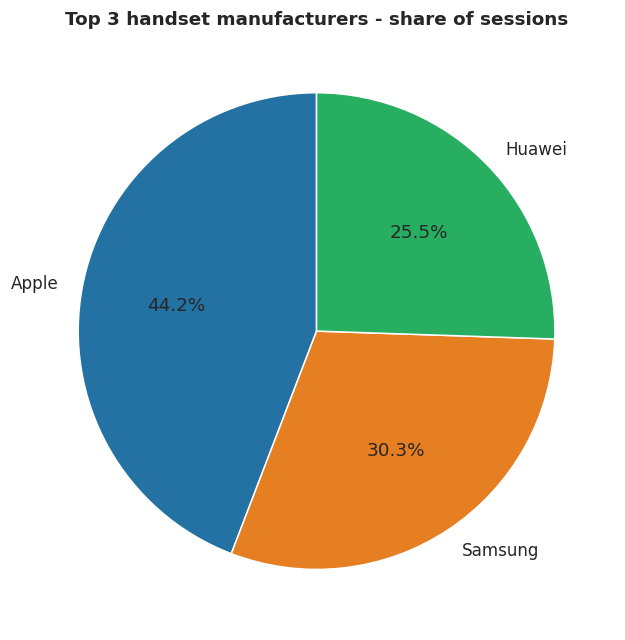

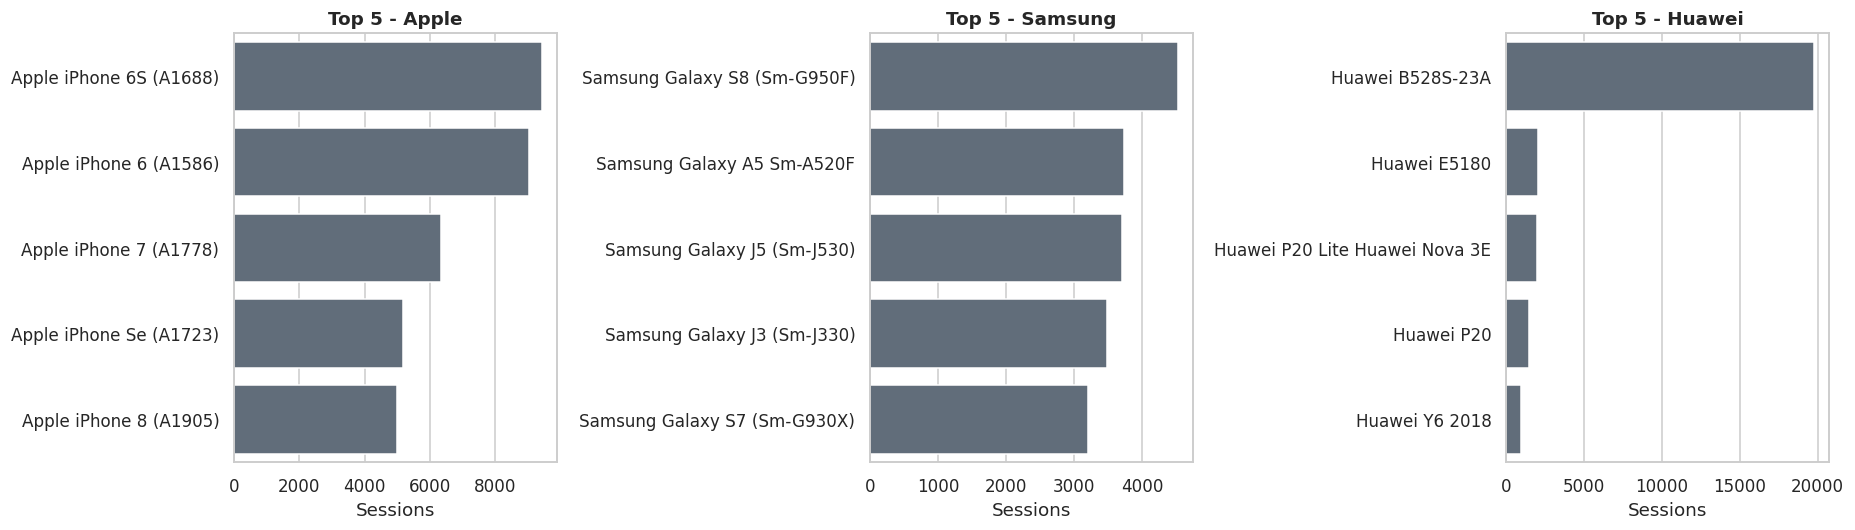

In [5]:
hs = raw.dropna(subset=["Handset Type"])
top10_handsets = hs["Handset Type"].value_counts().head(10)
print("TOP 10 HANDSETS\n", top10_handsets, "\n")
top3_mfr = hs["Handset Manufacturer"].value_counts().head(3)
print("TOP 3 MANUFACTURERS\n", top3_mfr, "\n")
top5_per_mfr = {m: hs[hs["Handset Manufacturer"] == m]["Handset Type"].value_counts().head(5)
                for m in top3_mfr.index}
for m, s in top5_per_mfr.items():
    print(f"Top 5 handsets - {m}\n{s}\n")

plt.figure(figsize=(9, 5))
sns.barplot(x=top10_handsets.values, y=top10_handsets.index, color="#2471a3")
plt.title("Top 10 handsets (xDR sessions)"); plt.xlabel("Sessions")
save_show("01_top10_handsets")

plt.figure(figsize=(6, 6))
plt.pie(top3_mfr.values, labels=top3_mfr.index, autopct="%1.1f%%",
        colors=["#2471a3", "#e67e22", "#27ae60"], startangle=90)
plt.title("Top 3 handset manufacturers - share of sessions")
save_show("02_top3_manufacturers")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (m, s) in zip(axes, top5_per_mfr.items()):
    sns.barplot(x=s.values, y=s.index, ax=ax, color="#5d6d7e")
    ax.set_title(f"Top 5 - {m}"); ax.set_xlabel("Sessions"); ax.set_ylabel("")
save_show("03_top5_per_manufacturer")

**Marketing interpretation**: Apple, Samsung and Huawei together dominate the base. The Huawei
B528S-23A (a home 4G router, not a phone) is the single most used device, which means a large
group of users are fixed-wireless / home-broadband customers. Marketing should (1) bundle data
plans with iPhone / Samsung flagship promotions, (2) create a home-internet package for router
users, and (3) bring in handset-specific offers for the older models (iPhone 6/6S) that still
make up a big share - they are natural upgrade targets.

### 1.1 Aggregate per user (MSISDN)

In [6]:
users_df = raw.dropna(subset=["MSISDN/Number"]).copy()
user_agg = users_df.groupby("MSISDN/Number").agg(
    n_sessions=("Bearer Id", "count"),
    total_duration_ms=("Dur. (ms)", "sum"),
    total_dl=("Total DL (Bytes)", "sum"),
    total_ul=("Total UL (Bytes)", "sum"),
    **{c: (c, "sum") for c in APP_TOTAL_COLS},
).reset_index()
user_agg["total_data"] = user_agg["total_dl"] + user_agg["total_ul"]
print(user_agg.shape)
user_agg.head()

(106856, 13)


,MSISDN/Number,n_sessions,total_duration_ms,total_dl,total_ul,Social Media Total (Bytes),Google Total (Bytes),Email Total (Bytes),Youtube Total (Bytes),Netflix Total (Bytes),Gaming Total (Bytes),Other Total (Bytes),total_data
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0,8.786906e+08
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0,1.568596e+08
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0,5.959665e+08
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0,4.223207e+08
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0,1.457411e+09


### 1.2 Exploratory Data Analysis

In [7]:
# (a) variables & dtypes
print(user_agg.dtypes)

# Treat missing + outliers (replace with mean) on the aggregated user table
num_cols = [c for c in user_agg.columns if c != "MSISDN/Number"]
print("Missing in aggregated table:", int(user_agg[num_cols].isna().sum().sum()))
user_clean = treat_missing(user_agg, num_cols)
user_clean, out_report = treat_outliers(user_clean, num_cols, k=3.0)
print("\nOutliers replaced by mean:\n", out_report)

MSISDN/Number                 float64
n_sessions                      int64
total_duration_ms             float64
total_dl                      float64
total_ul                      float64
Social Media Total (Bytes)    float64
Google Total (Bytes)          float64
Email Total (Bytes)           float64
Youtube Total (Bytes)         float64
Netflix Total (Bytes)         float64
Gaming Total (Bytes)          float64
Other Total (Bytes)           float64
total_data                    float64
dtype: object
Missing in aggregated table: 0

Outliers replaced by mean:
 n_sessions                     363
total_duration_ms             2591
total_dl                      1176
total_ul                      2866
Social Media Total (Bytes)     996
Google Total (Bytes)          1705
Email Total (Bytes)           1617
Youtube Total (Bytes)         2026
Netflix Total (Bytes)         2018
Gaming Total (Bytes)          1027
Other Total (Bytes)           1016
total_data                    1428
Name: outlie

In [8]:
# (b) basic metrics
basic = user_clean[num_cols].describe().T
basic["median"] = user_clean[num_cols].median()
print(basic.round(2).to_string())
basic.to_csv(f"{OUT_DIR}/basic_metrics.csv")

                               count          mean           std         min           25%          50%           75%           max       median
n_sessions                  106856.0  1.370000e+00  7.300000e-01         1.0  1.000000e+00          1.0  2.000000e+00  5.000000e+00          1.0
total_duration_ms           106856.0  1.284550e+05  9.040270e+04      7142.0  7.130800e+04     102740.0  1.709142e+05  4.771370e+05     102740.0
total_dl                    106856.0  6.093819e+08  3.976134e+08   8827082.0  3.148271e+08  570367723.0  7.971418e+08  2.284915e+09  570367723.0
total_ul                    106856.0  5.341072e+07  2.555800e+07   2866892.0  3.639547e+07   46793865.5  6.161261e+07  1.537323e+08   46793865.5
Social Media Total (Bytes)  106856.0  2.461402e+06  1.665039e+06      1563.0  1.211282e+06    2303756.0  3.271438e+06  9.594882e+06    2303756.0
Google Total (Bytes)        106856.0  1.034414e+07  6.104563e+06     40330.0  5.942636e+06    9586153.0  1.291033e+07  3.501994e+0

In [9]:
# (c) non-graphical univariate: dispersion parameters
disp = pd.DataFrame({
    "range": user_clean[num_cols].max() - user_clean[num_cols].min(),
    "variance": user_clean[num_cols].var(),
    "std": user_clean[num_cols].std(),
    "IQR": user_clean[num_cols].quantile(.75) - user_clean[num_cols].quantile(.25),
    "CV_%": user_clean[num_cols].std() / user_clean[num_cols].mean() * 100,
    "skewness": user_clean[num_cols].skew(),
    "kurtosis": user_clean[num_cols].kurt(),
})
print(disp.round(2).to_string())
disp.to_csv(f"{OUT_DIR}/dispersion.csv")

                                   range      variance           std           IQR   CV_%  skewness  kurtosis
n_sessions                  4.000000e+00  5.300000e-01  7.300000e-01  1.000000e+00  53.01      2.42      6.63
total_duration_ms           4.699950e+05  8.172649e+09  9.040270e+04  9.960625e+04  70.38      1.29      1.68
total_dl                    2.276088e+09  1.580964e+17  3.976134e+08  4.823147e+08  65.25      1.12      1.67
total_ul                    1.508654e+08  6.532115e+14  2.555800e+07  2.521713e+07  47.85      1.35      1.73
Social Media Total (Bytes)  9.593319e+06  2.772355e+12  1.665039e+06  2.060156e+06  67.65      1.10      1.65
Google Total (Bytes)        3.497961e+07  3.726569e+13  6.104563e+06  6.967690e+06  59.01      1.16      1.62
Email Total (Bytes)         1.034667e+07  3.286825e+12  1.812960e+06  2.098580e+06  60.49      1.14      1.62
Youtube Total (Bytes)       9.573350e+07  2.780203e+14  1.667394e+07  1.815113e+07  55.94      1.18      1.62
Netflix To

Interpretation: the coefficient of variation is high for almost all volume metrics, i.e. usage
is very unequal across users. Positive skewness means a small group of heavy users pulls the
mean above the median - so medians describe the *typical* customer better than means.

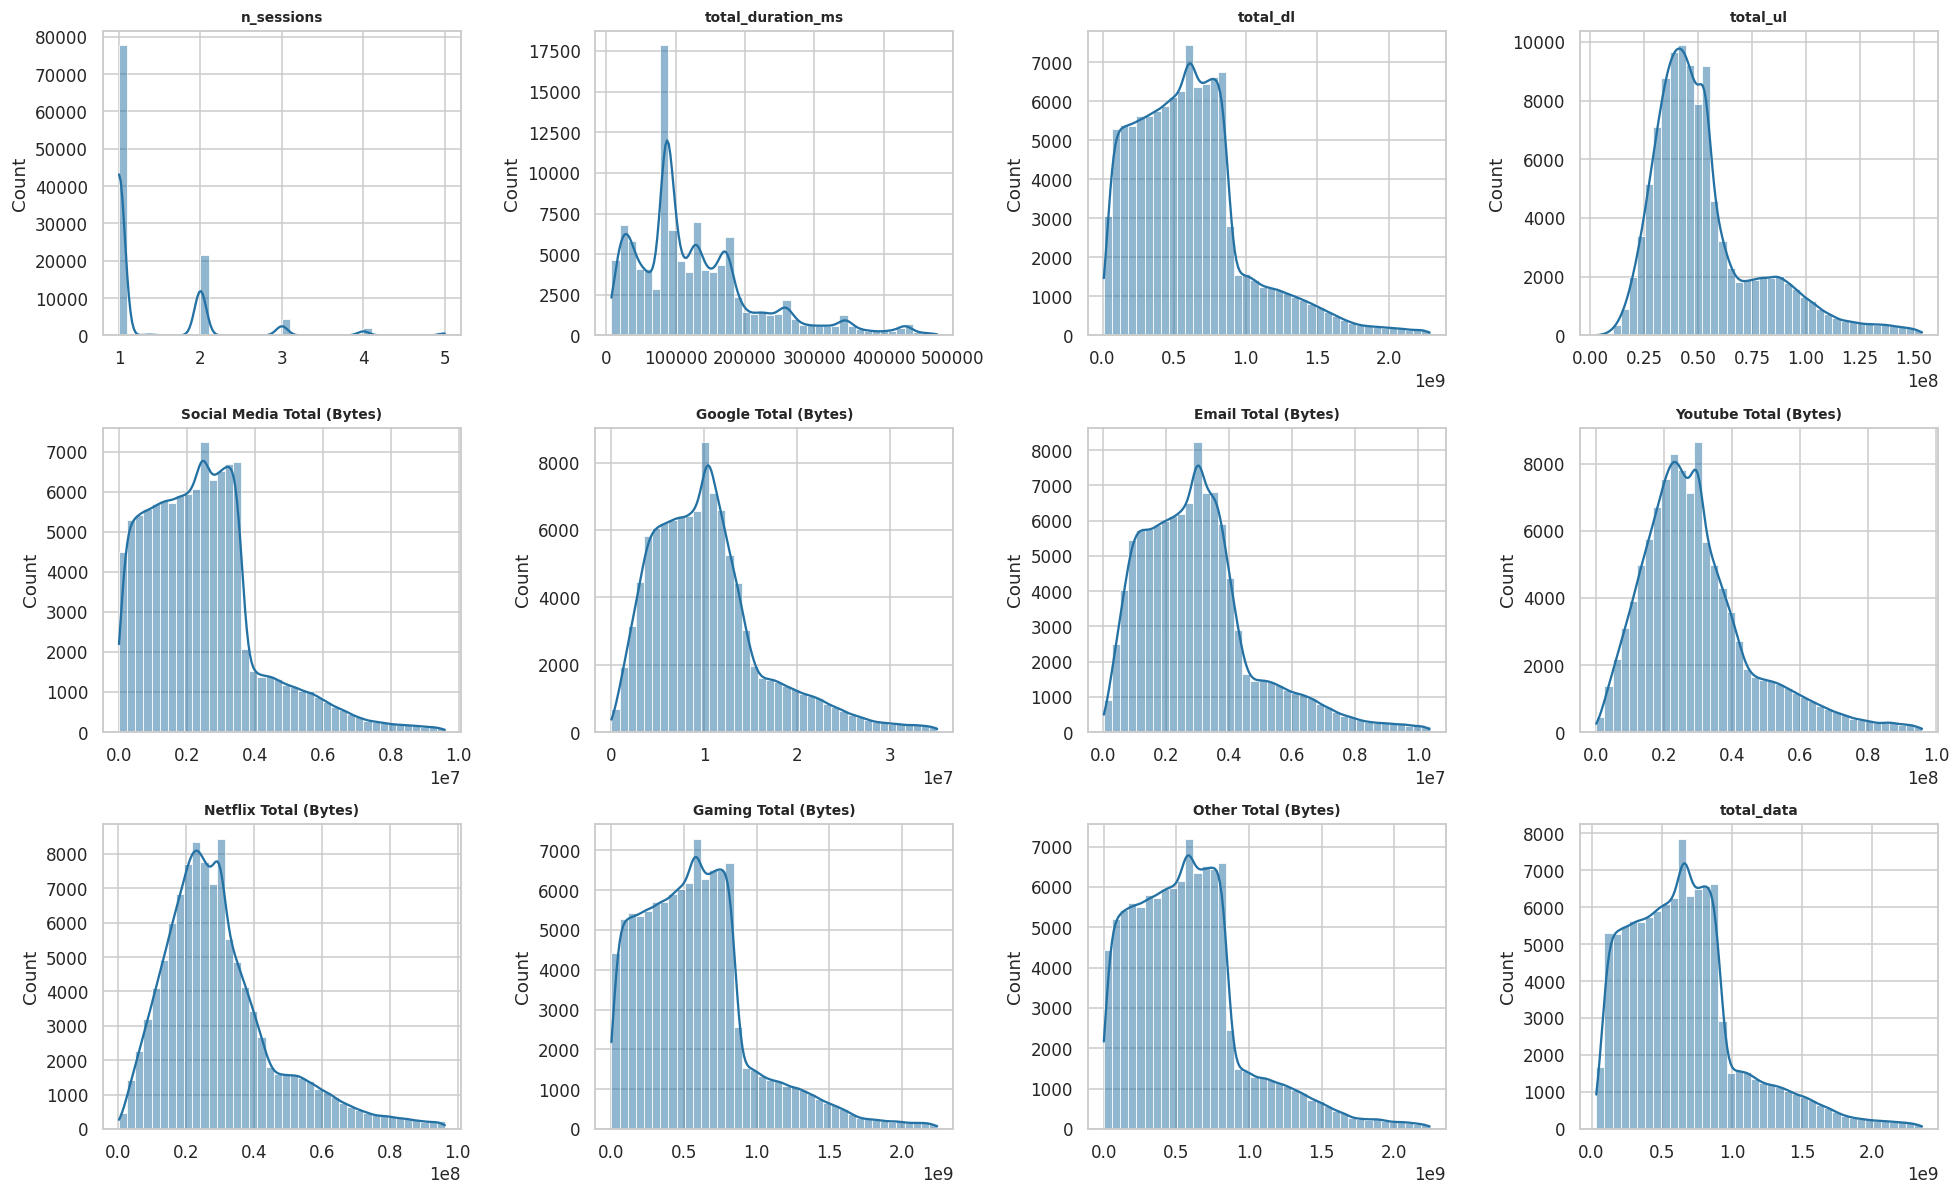

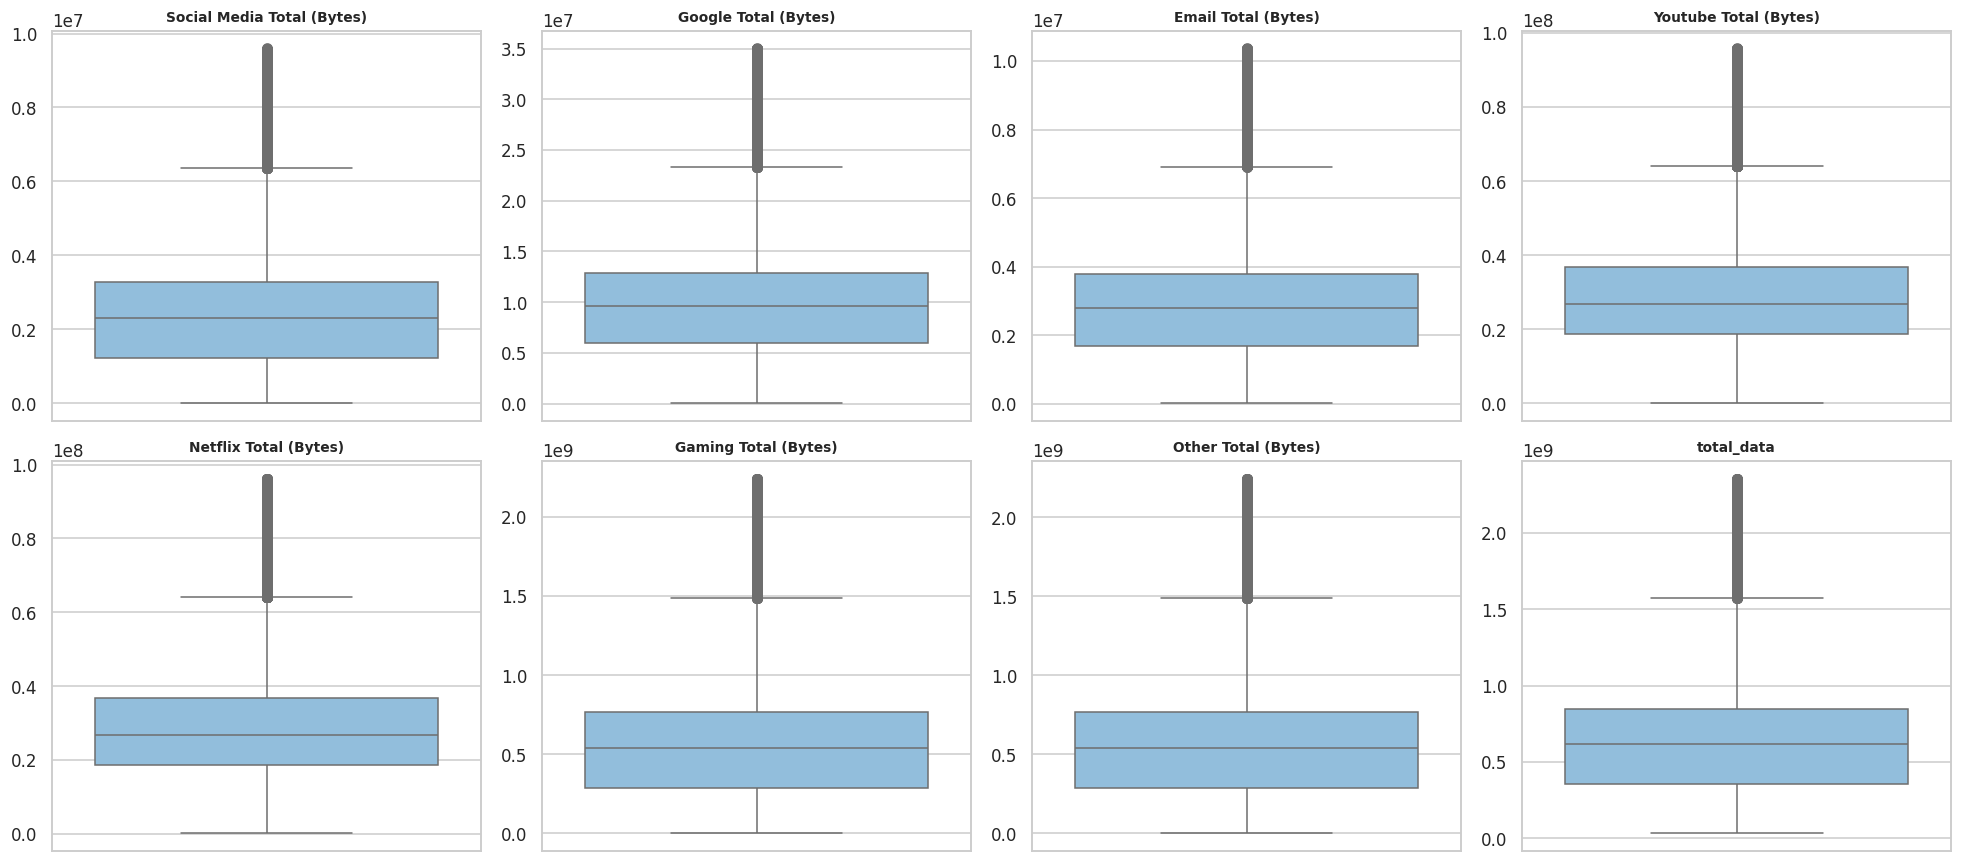

In [10]:
# (d) graphical univariate: histograms + boxplots
fig, axes = plt.subplots(3, 4, figsize=(18, 11))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(user_clean[c], bins=40, kde=True, ax=ax, color="#2471a3")
    ax.set_title(c, fontsize=9); ax.set_xlabel("")
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
save_show("04_histograms")

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), APP_TOTAL_COLS + ["total_data"]):
    sns.boxplot(y=user_clean[c], ax=ax, color="#85c1e9")
    ax.set_title(c, fontsize=9); ax.set_ylabel("")
save_show("05_boxplots_apps")

Gaming Total (Bytes)          0.965
Youtube Total (Bytes)         0.533
Netflix Total (Bytes)         0.532
Google Total (Bytes)          0.515
Email Total (Bytes)           0.496
Social Media Total (Bytes)    0.476
Other Total (Bytes)           0.471
dtype: float64


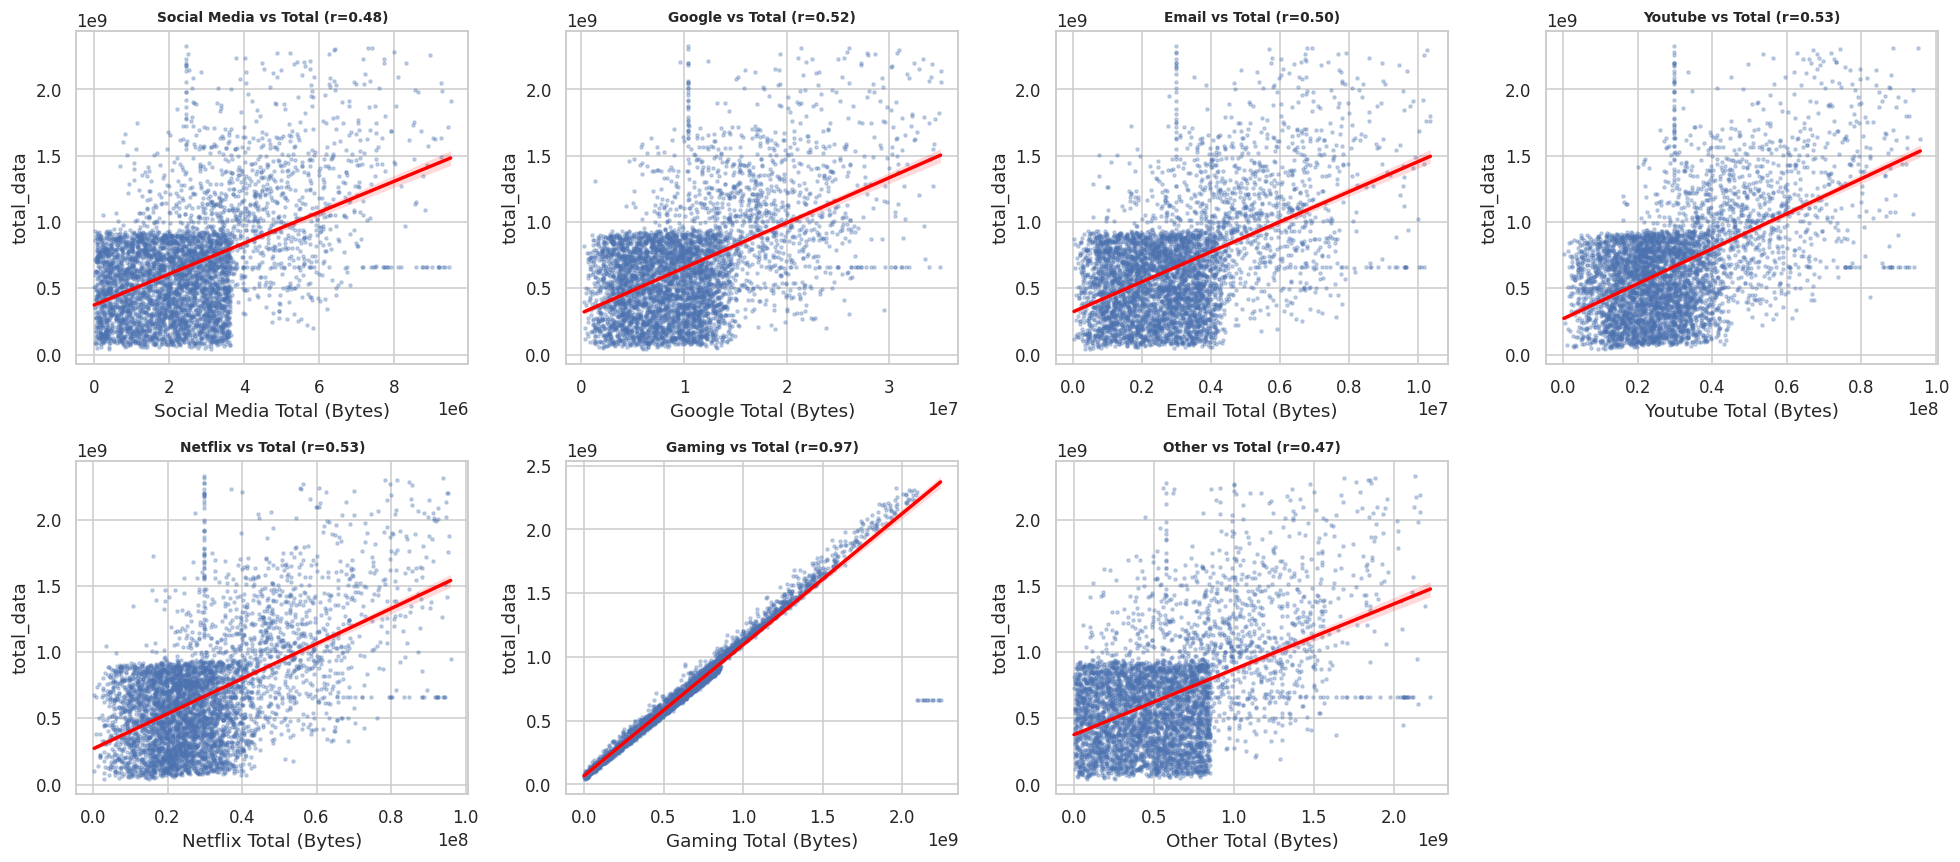

In [11]:
# (e) bivariate: each application vs total DL+UL
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
biv = {}
for ax, c in zip(axes.ravel(), APP_TOTAL_COLS):
    sample = user_clean.sample(5000, random_state=RANDOM_STATE)
    sns.regplot(x=sample[c], y=sample["total_data"], ax=ax,
                scatter_kws={"s": 4, "alpha": .3}, line_kws={"color": "red"})
    r, p = stats.pearsonr(user_clean[c], user_clean["total_data"])
    biv[c] = r
    ax.set_title(f"{c.replace(' Total (Bytes)', '')} vs Total (r={r:.2f})", fontsize=9)
axes.ravel()[-1].axis("off")
save_show("06_bivariate_app_vs_total")
print(pd.Series(biv).round(3).sort_values(ascending=False))

  duration_decile  users  total_duration_ms  total_data_bytes  total_data_GB
5              D6  11776       1.391933e+09      8.570849e+12        7982.23
6              D7   9596       1.360771e+09      5.454771e+12        5080.15
7              D8  10685       1.804640e+09      7.416789e+12        6907.42
8              D9  10685       2.282094e+09      8.434583e+12        7855.32
9             D10  10686       3.564398e+09      1.147742e+13       10689.18


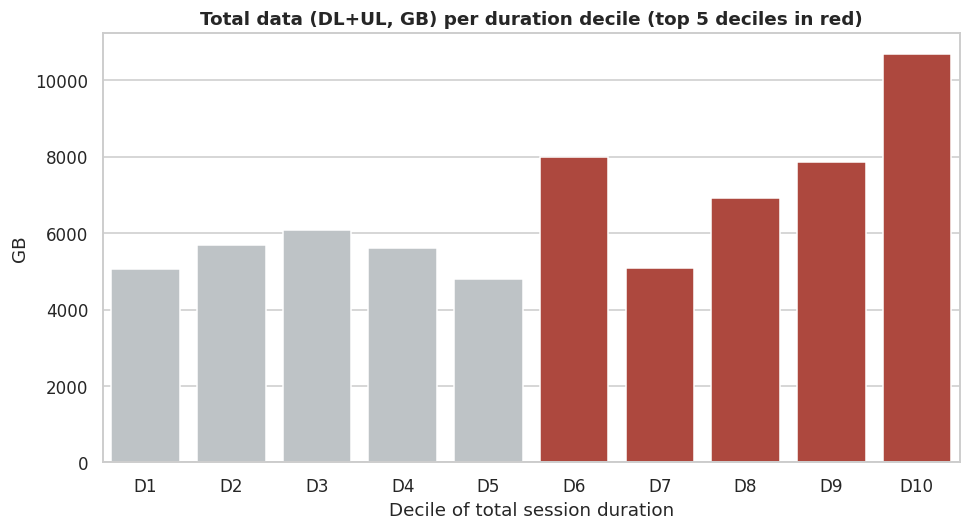

In [12]:
# (f) variable transformation: deciles by total duration -> top five deciles
user_clean["duration_decile"] = pd.qcut(user_clean["total_duration_ms"], 10,
                                        labels=[f"D{i}" for i in range(1, 11)])
decile = user_clean.groupby("duration_decile").agg(
    users=("MSISDN/Number", "count"),
    total_duration_ms=("total_duration_ms", "sum"),
    total_data_bytes=("total_data", "sum"),
).reset_index()
decile["total_data_GB"] = decile["total_data_bytes"] / 1024 ** 3
top5_deciles = decile.tail(5)          # D6..D10 are the five highest-duration deciles
print(top5_deciles.round(2).to_string())
decile.to_csv(f"{OUT_DIR}/decile_data.csv", index=False)

plt.figure(figsize=(9, 5))
colors = ["#bdc3c7"] * 5 + ["#c0392b"] * 5
sns.barplot(data=decile, x="duration_decile", y="total_data_GB", palette=colors)
plt.title("Total data (DL+UL, GB) per duration decile (top 5 deciles in red)")
plt.xlabel("Decile of total session duration"); plt.ylabel("GB")
save_show("07_decile_total_data")

              Social Media  Google  Email  Youtube  Netflix  Gaming  Other
Social Media         1.000   0.486  0.479    0.490    0.495   0.455  0.459
Google               0.486   1.000  0.515    0.540    0.540   0.480  0.483
Email                0.479   0.515  1.000    0.525    0.526   0.468  0.476
Youtube              0.490   0.540  0.525    1.000    0.559   0.487  0.492
Netflix              0.495   0.540  0.526    0.559    1.000   0.487  0.491
Gaming               0.455   0.480  0.468    0.487    0.487   1.000  0.451
Other                0.459   0.483  0.476    0.492    0.491   0.451  1.000


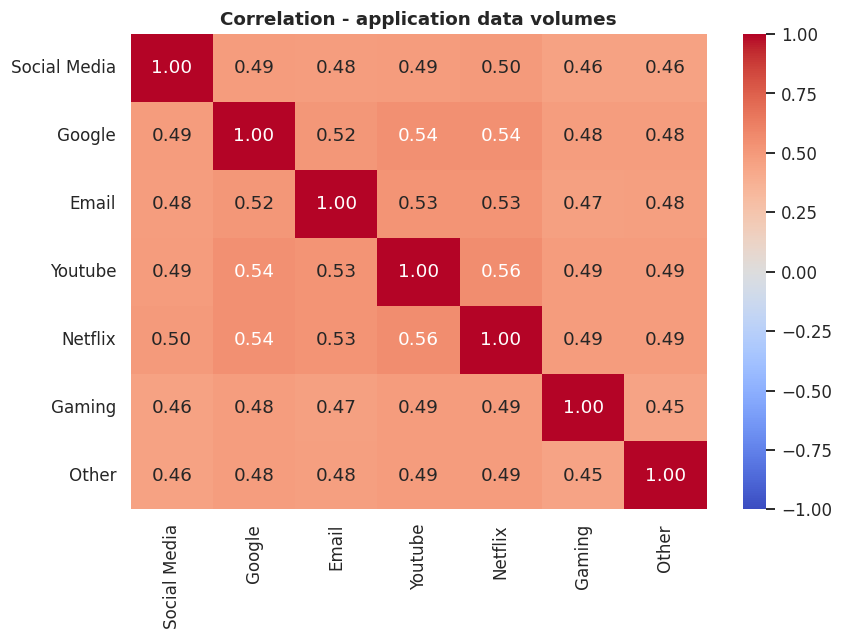

In [13]:
# (g) correlation matrix of the 7 application volumes
corr = user_clean[APP_TOTAL_COLS].corr()
corr.index = corr.columns = APPS
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation - application data volumes")
save_show("08_correlation_heatmap")
print(corr.round(3))

Interpretation: all application volumes are moderately and positively correlated (r about
0.45-0.50, no negative values). Users who use a lot of one app tend to use more of every app, i.e.
overall "heaviness" drives usage more than app preference. No pair is strongly correlated
(> 0.8), so there is no redundancy - each app brings extra information.

Explained variance: [0.567 0.079 0.077 0.077 0.07  0.066 0.063] 
Cumulative: [0.567 0.646 0.724 0.801 0.871 0.937 1.   ]
                PC1    PC2    PC3
Social Media  0.366 -0.046 -0.174
Google        0.386 -0.106 -0.212
Email         0.380 -0.181 -0.236
Youtube       0.392 -0.111 -0.181
Netflix       0.392 -0.109 -0.200
Gaming        0.362  0.909  0.182
Other         0.365 -0.320  0.874


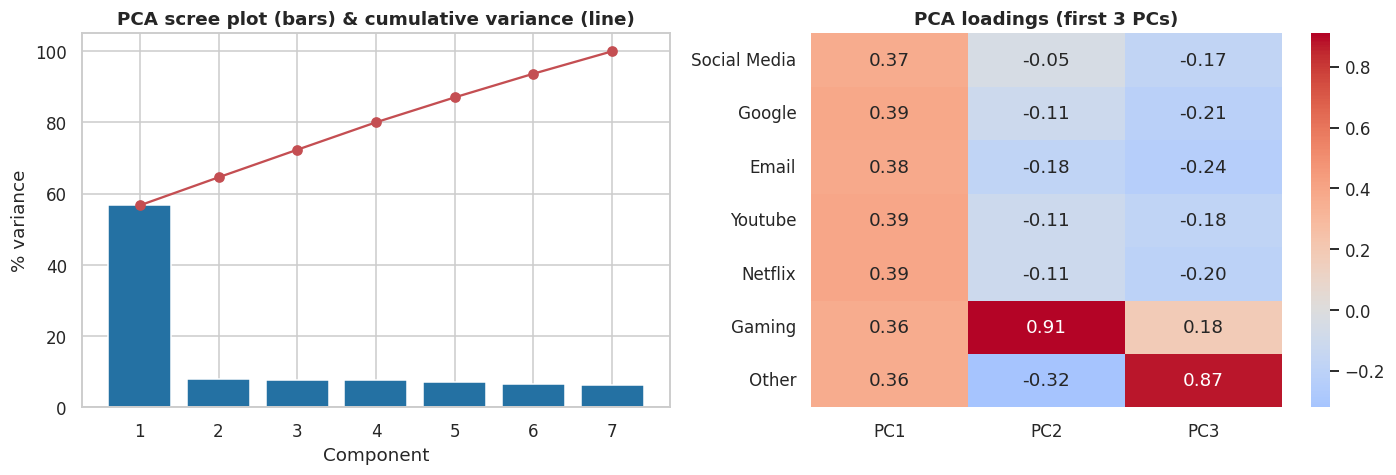

In [14]:
# (h) PCA
X = StandardScaler().fit_transform(user_clean[APP_TOTAL_COLS])
pca = PCA().fit(X)
evr = pca.explained_variance_ratio_
print("Explained variance:", evr.round(3), "\nCumulative:", evr.cumsum().round(3))
loadings = pd.DataFrame(pca.components_[:3].T, index=APPS, columns=["PC1", "PC2", "PC3"])
print(loadings.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(range(1, 8), evr * 100, color="#2471a3")
ax[0].plot(range(1, 8), evr.cumsum() * 100, "o-r")
ax[0].set_title("PCA scree plot (bars) & cumulative variance (line)")
ax[0].set_xlabel("Component"); ax[0].set_ylabel("% variance")
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("PCA loadings (first 3 PCs)")
save_show("09_pca")

**PCA interpretation (4 points)**
1. PC1 alone explains ~56.7% of variance and has almost equal positive loadings (0.36-0.39) on
   all 7 apps -> it is a general "overall data usage / heavy-user" factor.
2. PC2 (7.9%) is dominated by Gaming (+0.91) and PC3 (7.7%) by Other (+0.87): gaming and
   "other" traffic behave differently from the rest of the apps.
3. The first 3 PCs explain ~72% and 5 PCs ~87%, so 7 dimensions can be reduced to 2-3 with a
   moderate information loss (PC1 for segmentation, PC2 for gaming users).
4. Marketing implication: segment users first by overall volume (PC1), then offer gaming
   add-ons to the high-PC2 group.

# TASK 2 - USER ENGAGEMENT ANALYSIS

       MSISDN/Number  sessions  duration_ms       traffic
count   1.068560e+05  106856.0     106856.0  1.068560e+05
mean    4.511474e+10       1.4     146167.2  6.909621e+08
std     2.889423e+12       0.8     186358.7  4.910559e+08
min     3.360100e+10       1.0       7142.0  3.324901e+07
25%     3.365088e+10       1.0      71308.0  3.585499e+08
50%     3.366365e+10       1.0     102740.0  6.179231e+08
75%     3.368344e+10       2.0     172799.0  8.574351e+08
max     8.823971e+14      18.0   18553754.0  8.846226e+09

Top 10 customers by sessions
  MSISDN/Number  sessions
  3.362632e+10        18
  3.361489e+10        17
  3.362578e+10        17
  3.365973e+10        16
  3.367588e+10        15
  3.376054e+10        15
  3.366716e+10        13
  3.360313e+10        12
  3.360452e+10        12
  3.362708e+10        12

Top 10 customers by duration_ms
  MSISDN/Number  duration_ms
  3.362578e+10   18553754.0
  3.361489e+10    9966898.0
  3.376054e+10    9279434.0
  3.362632e+10    8791927.

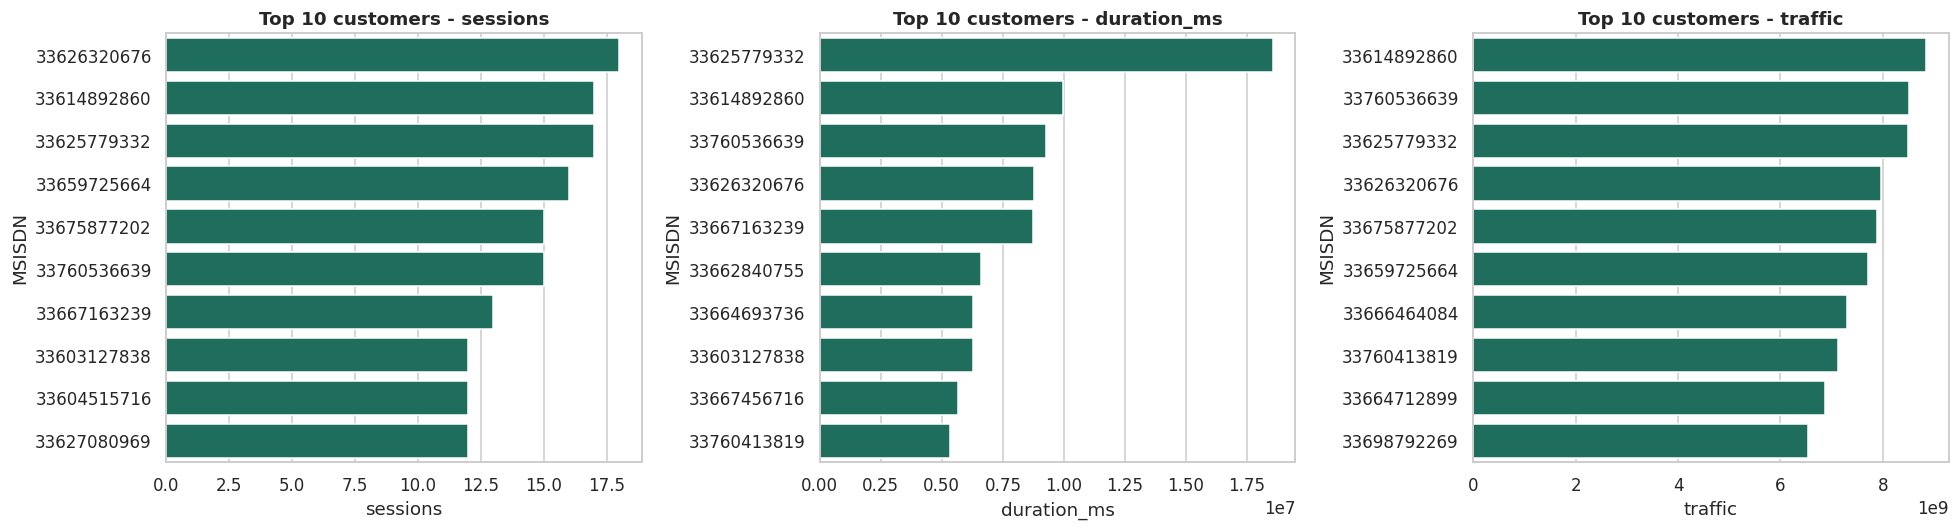

In [15]:
eng = users_df.groupby("MSISDN/Number").agg(
    sessions=("Bearer Id", "count"),
    duration_ms=("Dur. (ms)", "sum"),
    traffic=("Total Data (Bytes)", "sum"),
).reset_index()
# engagement keeps raw values (heavy users are the signal); no missing values after groupby
print(eng.describe().round(1))

top10 = {m: eng.nlargest(10, m)[["MSISDN/Number", m]] for m in ["sessions", "duration_ms", "traffic"]}
for m, t in top10.items():
    print(f"\nTop 10 customers by {m}\n", t.to_string(index=False))
    t.to_csv(f"{OUT_DIR}/top10_{m}.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (m, t) in zip(axes, top10.items()):
    sns.barplot(x=t[m], y=t["MSISDN/Number"].astype(int).astype(str), ax=ax, color="#117a65")
    ax.set_title(f"Top 10 customers - {m}"); ax.set_ylabel("MSISDN")
save_show("10_top10_engagement")

segment           High engagement  Low engagement  Medium engagement
sessions    min      3.000000e+00    1.000000e+00       2.000000e+00
            max      1.800000e+01    2.000000e+00       4.000000e+00
            mean     4.300000e+00    1.000000e+00       2.200000e+00
            sum      1.721700e+04    8.459500e+04       4.712300e+04
duration_ms min      4.689600e+04    7.142000e+03       1.823500e+04
            max      1.855375e+07    1.573420e+06       3.174824e+06
            mean     5.705968e+05    1.069952e+05       2.136755e+05
            sum      2.309776e+09    8.684055e+09       4.625007e+09
traffic     min      1.085994e+09    3.324901e+07       2.842182e+08
            max      8.846226e+09    9.507607e+08       1.873330e+09
            mean     2.283232e+09    4.955131e+08       1.126061e+09
            sum      9.242524e+12    4.021733e+13       2.437359e+13
segment
Low engagement       81163
Medium engagement    21645
High engagement       4048
Name: count, d

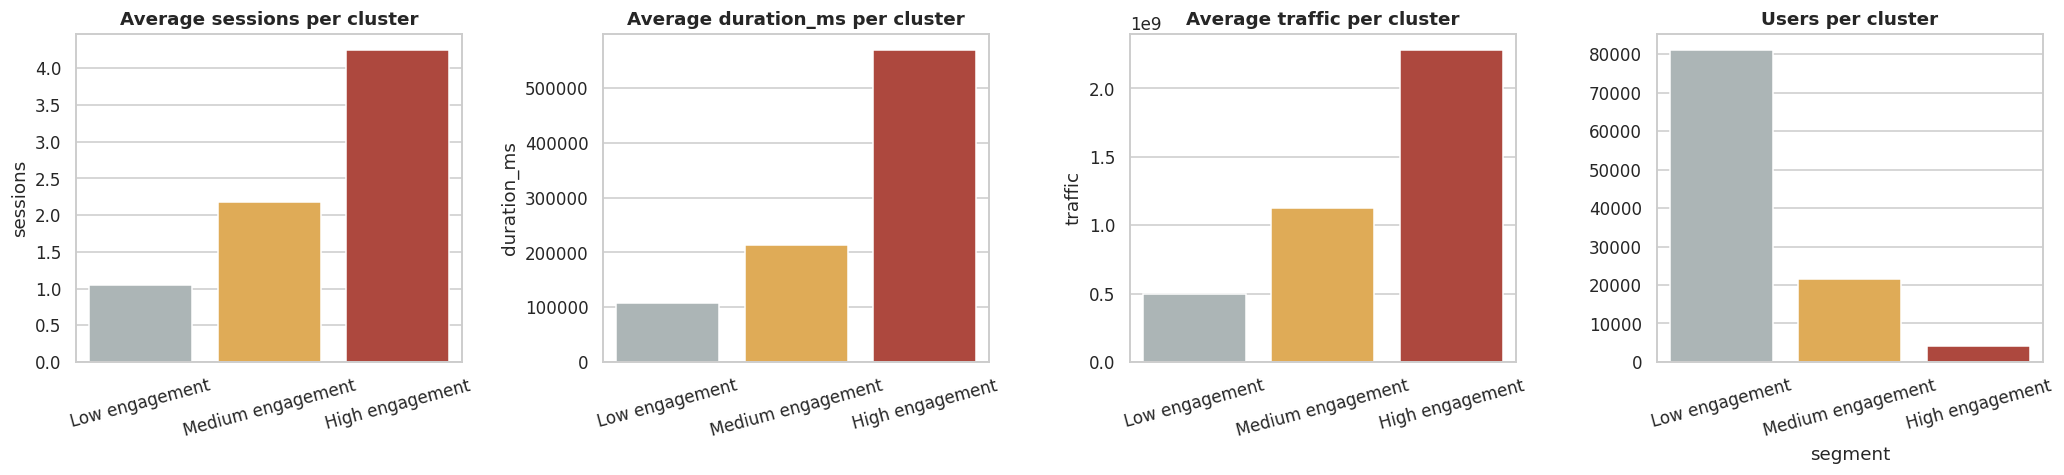

In [16]:
# Normalise + k-means (k=3)
eng_cols = ["sessions", "duration_ms", "traffic"]
mm = MinMaxScaler()
eng_norm = pd.DataFrame(mm.fit_transform(eng[eng_cols]), columns=eng_cols)
km3 = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(eng_norm)
eng["cluster"] = km3.labels_

# label clusters by mean traffic (low -> high)
order = eng.groupby("cluster")["traffic"].mean().sort_values().index.tolist()
names = {order[0]: "Low engagement", order[1]: "Medium engagement", order[2]: "High engagement"}
eng["segment"] = eng["cluster"].map(names)

cl_stats = eng.groupby("segment")[eng_cols].agg(["min", "max", "mean", "sum"]).round(1)
cl_stats.loc[:, :] = cl_stats.values
print(cl_stats.T.to_string())
cl_stats.to_csv(f"{OUT_DIR}/engagement_cluster_stats.csv")
print(eng["segment"].value_counts())

summary = eng.groupby("segment")[eng_cols].mean()
summary = summary.loc[["Low engagement", "Medium engagement", "High engagement"]]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, c in zip(axes[:3], eng_cols):
    sns.barplot(x=summary.index, y=summary[c], ax=ax, palette=["#aab7b8", "#f5b041", "#c0392b"])
    ax.set_title(f"Average {c} per cluster"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
cnt = eng["segment"].value_counts().loc[summary.index]
sns.barplot(x=cnt.index, y=cnt.values, ax=axes[3], palette=["#aab7b8", "#f5b041", "#c0392b"])
axes[3].set_title("Users per cluster"); axes[3].tick_params(axis="x", rotation=15)
save_show("11_engagement_clusters")


Top 10 engaged users - Social Media
 MSISDN/Number
3.362632e+10    43374779.0
3.376054e+10    39783189.0
3.365973e+10    35412358.0
3.361489e+10    28294544.0
3.362578e+10    27135500.0
3.366716e+10    24247850.0
3.378632e+10    23974919.0
3.366907e+10    23800834.0
3.360313e+10    23077825.0
3.365849e+10    23000066.0

Top 10 engaged users - Google
 MSISDN/Number
3.362632e+10    152191852.0
3.362578e+10    142307915.0
3.361489e+10    127973787.0
3.376054e+10    123223099.0
3.365973e+10    116516345.0
3.378632e+10    110254484.0
3.367588e+10    109860502.0
3.366716e+10    105032696.0
3.376127e+10     97089988.0
3.369876e+10     91935151.0

Top 10 engaged users - Email
 MSISDN/Number
3.362632e+10    42418782.0
3.361489e+10    40788634.0
3.362578e+10    40633966.0
3.378632e+10    36310123.0
3.365973e+10    35999792.0
3.376054e+10    33693767.0
3.367588e+10    31514421.0
3.366546e+10    30417885.0
3.366716e+10    30335796.0
3.369879e+10    29059042.0

Top 10 engaged users - Youtube
 MSIS

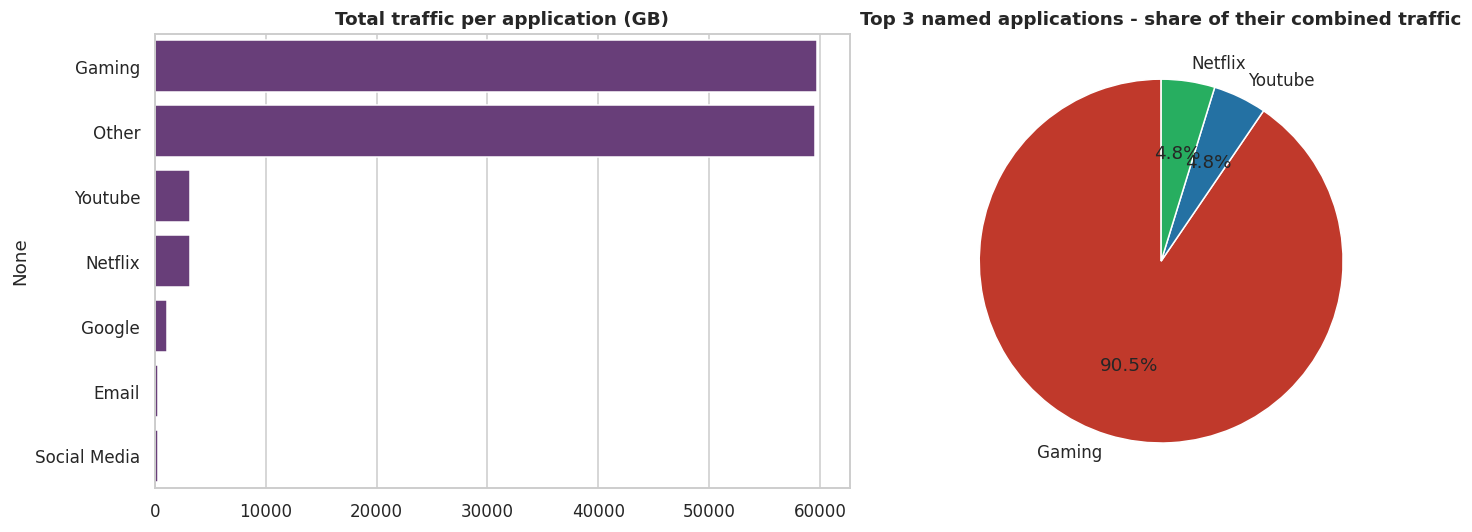

In [17]:
# Per-application traffic -> top 10 engaged users per app, top 3 apps
app_user = users_df.groupby("MSISDN/Number")[APP_TOTAL_COLS].sum()
top10_app = {}
for a, c in zip(APPS, APP_TOTAL_COLS):
    top10_app[a] = app_user[c].nlargest(10)
    print(f"\nTop 10 engaged users - {a}\n", top10_app[a].to_string())
pd.concat(top10_app, axis=1).to_csv(f"{OUT_DIR}/top10_users_per_app.csv")

app_totals = app_user.sum()
app_totals.index = APPS
app_totals_gb = (app_totals / 1024 ** 3).sort_values(ascending=False)
print(app_totals_gb.round(1))
top3_apps = app_totals_gb.drop("Other").head(3)    # 'Other' is a catch-all, not one app

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x=app_totals_gb.values, y=app_totals_gb.index, ax=ax[0], color="#6c3483")
ax[0].set_title("Total traffic per application (GB)")
ax[1].pie(top3_apps.values, labels=top3_apps.index, autopct="%1.1f%%",
          colors=["#c0392b", "#2471a3", "#27ae60"], startangle=90)
ax[1].set_title("Top 3 named applications - share of their combined traffic")
save_show("12_top_apps")

Optimal k (elbow): 3


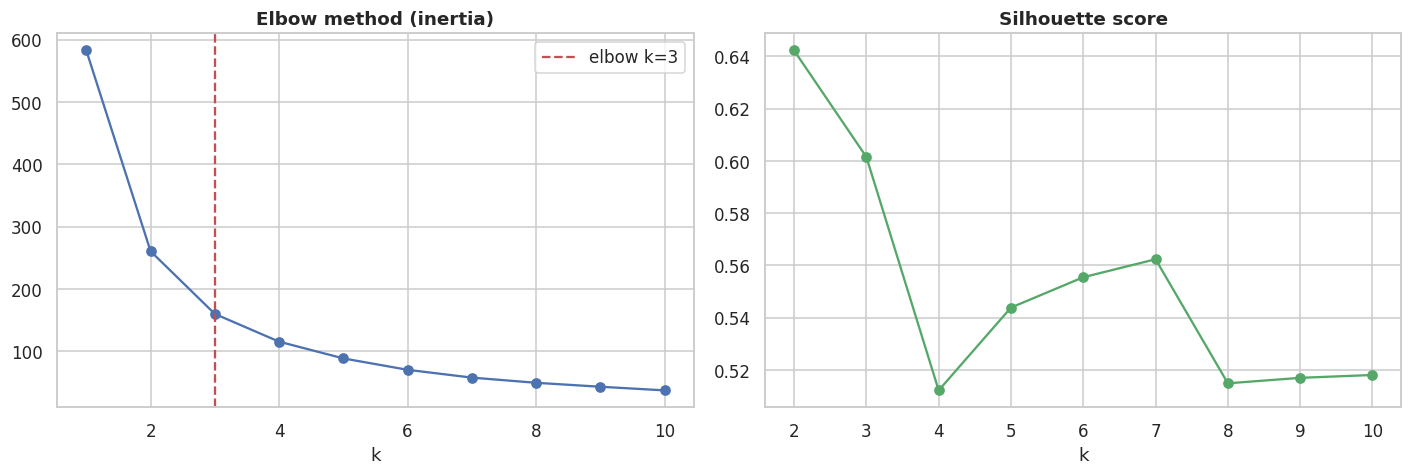

In [18]:
# Elbow method for optimal k
inertia, sil = [], []
from sklearn.metrics import silhouette_score
ks = range(1, 11)
for k in ks:
    m = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(eng_norm)
    inertia.append(m.inertia_)
    if k > 1:
        idx = np.random.RandomState(0).choice(len(eng_norm), 10000, replace=False)
        sil.append(silhouette_score(eng_norm.iloc[idx], m.labels_[idx]))
# elbow = point with maximum distance to the line joining first and last point
x = np.array(list(ks)); y = np.array(inertia)
p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
d = [abs(np.cross(p2 - p1, p1 - np.array([xi, yi]))) / np.linalg.norm(p2 - p1) for xi, yi in zip(x, y)]
best_k = int(x[int(np.argmax(d))])
print("Optimal k (elbow):", best_k)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(ks, inertia, "o-"); ax[0].axvline(best_k, color="r", ls="--", label=f"elbow k={best_k}")
ax[0].set_title("Elbow method (inertia)"); ax[0].set_xlabel("k"); ax[0].legend()
ax[1].plot(range(2, 11), sil, "o-g"); ax[1].set_title("Silhouette score"); ax[1].set_xlabel("k")
save_show("13_elbow")

# TASK 3 - EXPERIENCE ANALYTICS

In [19]:
exp_raw = users_df.copy()
exp_raw["tcp"] = exp_raw[["TCP DL Retrans. Vol (Bytes)", "TCP UL Retrans. Vol (Bytes)"]].sum(axis=1, min_count=1)
exp_raw["rtt"] = exp_raw[["Avg RTT DL (ms)", "Avg RTT UL (ms)"]].sum(axis=1, min_count=1)
exp_raw["tp"] = exp_raw[["Avg Bearer TP DL (kbps)", "Avg Bearer TP UL (kbps)"]].sum(axis=1, min_count=1)

# session level cleaning (missing -> mean / mode, outliers -> mean)
exp_raw = treat_missing(exp_raw, ["tcp", "rtt", "tp"], ["Handset Type"])
exp_raw, exp_out = treat_outliers(exp_raw, ["tcp", "rtt", "tp"], k=3.0)
print("Outliers replaced:\n", exp_out)

exp_user = exp_raw.groupby("MSISDN/Number").agg(
    avg_tcp=("tcp", "mean"),
    avg_rtt=("rtt", "mean"),
    avg_tp=("tp", "mean"),
    handset=("Handset Type", lambda s: s.mode().iloc[0]),
).reset_index()
print(exp_user.describe().round(2))
exp_user.head()

Outliers replaced:
 tcp    1761
rtt    4903
tp     3791
Name: outliers_replaced, dtype: int64
       MSISDN/Number      avg_tcp    avg_rtt     avg_tp
count   1.068560e+05    106856.00  106856.00  106856.00
mean    4.511474e+10  13884428.35      82.92   10866.89
std     2.889423e+12   9335616.13      55.19   17815.66
min     3.360100e+10         2.00       0.00       0.00
25%     3.365088e+10   3441554.75      40.50      92.00
50%     3.366365e+10  20594294.63      68.31     211.00
75%     3.368344e+10  20594294.63     125.84   15834.00
max     8.823971e+14  79098491.00     383.00   88994.00


,MSISDN/Number,avg_tcp,avg_rtt,avg_tp,handset
0,3.360100e+10,2.059429e+07,46.000000,76.0,Huawei P20 Lite Huawei Nova 3E
1,3.360100e+10,2.059429e+07,31.000000,99.0,Apple iPhone 7 (A1778)
2,3.360100e+10,2.059429e+07,125.835689,97.0,Huawei B528S-23A
3,3.360101e+10,1.066000e+03,84.000000,248.0,Apple iPhone 5S (A1457)
4,3.360101e+10,1.498256e+07,59.500000,28422.0,Apple iPhone Se (A1723)


In [20]:
# 3.2 top / bottom / most frequent 10 values (session level)
def top_bottom_freq(s, name):
    out = pd.concat({
        "top10": pd.Series(s.nlargest(10).values),
        "bottom10": pd.Series(s.nsmallest(10).values),
        "most_frequent10": pd.Series(s.round(2).value_counts().head(10).index.values),
        "frequency": pd.Series(s.round(2).value_counts().head(10).values),
    }, axis=1)
    print(f"\n=== {name} ===\n", out.to_string())
    out.to_csv(f"{OUT_DIR}/top_bottom_freq_{name}.csv", index=False)
    return out

tbf_tcp = top_bottom_freq(exp_raw["tcp"], "TCP_retransmission")
tbf_rtt = top_bottom_freq(exp_raw["rtt"], "RTT")
tbf_tp = top_bottom_freq(exp_raw["tp"], "Throughput")


=== TCP_retransmission ===
         top10  bottom10  most_frequent10  frequency
0  79176999.0       2.0      20594294.63      84973
1  79176214.0       2.0      13682497.99       1761
2  79116028.0       3.0          1294.00        649
3  79098491.0       3.0          1330.00        489
4  78877043.0       3.0          2660.00        244
5  78800473.0       3.0          1318.00        235
6  78785444.0       3.0          3990.00        138
7  78700632.0       4.0            38.00        138
8  78585575.0       4.0            92.00        131
9  78525949.0       4.0          2636.00        108

=== RTT ===
    top10  bottom10  most_frequent10  frequency
0  383.0       0.0           125.84      27616
1  383.0       0.0            29.00       4990
2  383.0       0.0            82.99       4903
3  383.0       0.0            39.00       4210
4  383.0       0.0            38.00       2755
5  383.0       1.0            40.00       2639
6  383.0       1.0            30.00       2591
7  383.0 


Lowest avg throughput handsets (>=100 users):
                                mean  median  count
handset                                           
Zte Mf259                     170.9   182.5    162
Apple iPhone 4 (A1332)       1234.2   376.0    183
Apple iPhone 4S (A1387)      1696.9   485.0    195
Samsung Sm-G390F             2382.7    15.0    427
Samsung Galaxy J5 (Sm-J530)  3324.2    78.0   2748

Highest avg throughput handsets (>=100 users):
                                   mean   median  count
handset                                               
Huawei E5573B                  24764.6  22433.0    117
Huawei B528S-23A               24998.5  21504.0  17285
Xiaomi Communica. Redmi Note5  26009.0  22550.0    136
Huawei E5180                   29650.5  28367.5   1182
Huawei E5573                   31817.3  31626.5    206

Highest TCP retransmission (>=100 users):
                                     mean  count
handset                                        
Apple iPhone 6S (A168

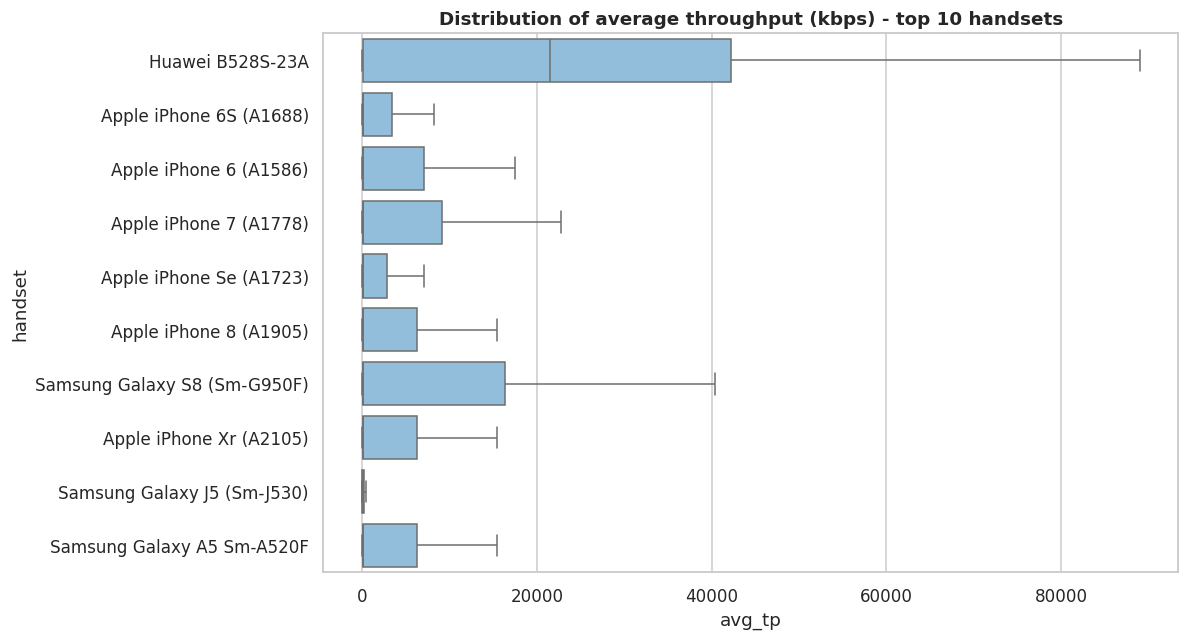

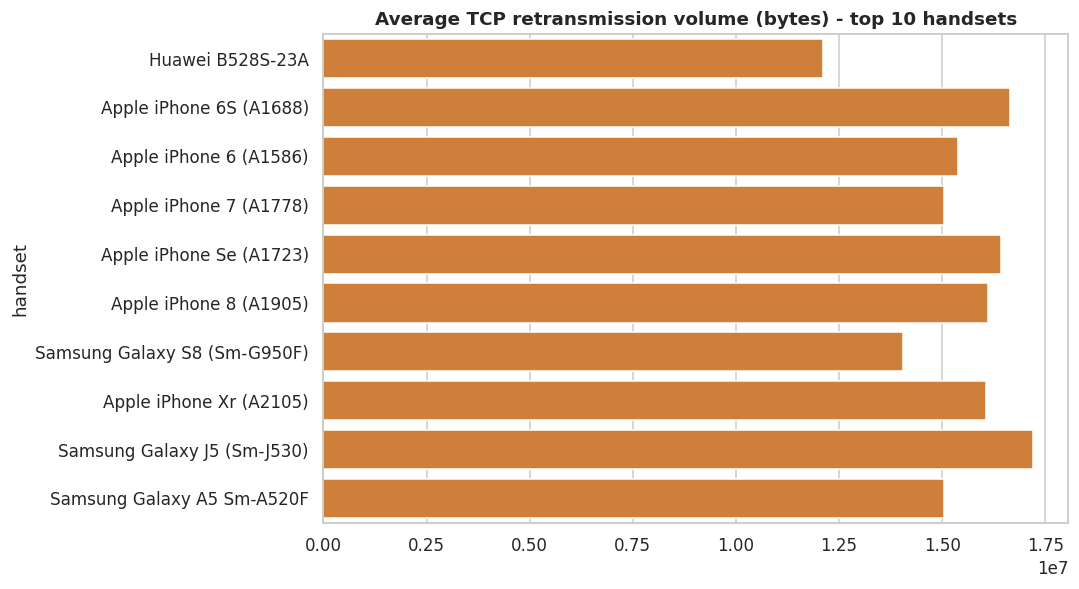

In [21]:
# 3.3 per handset type
top_h = exp_user["handset"].value_counts().head(10).index
sub = exp_user[exp_user["handset"].isin(top_h)]

plt.figure(figsize=(11, 6))
sns.boxplot(data=sub, y="handset", x="avg_tp", order=top_h, color="#85c1e9", showfliers=False)
plt.title("Distribution of average throughput (kbps) - top 10 handsets")
save_show("14_throughput_per_handset")

tcp_h = sub.groupby("handset")["avg_tcp"].mean().loc[top_h]
plt.figure(figsize=(10, 5.5))
sns.barplot(x=tcp_h.values, y=tcp_h.index, color="#e67e22")
plt.title("Average TCP retransmission volume (bytes) - top 10 handsets")
save_show("15_tcp_per_handset")

tp_h = exp_user.groupby("handset")["avg_tp"].agg(["mean", "median", "count"])
tp_h = tp_h[tp_h["count"] >= 100].sort_values("mean")
print("\nLowest avg throughput handsets (>=100 users):\n", tp_h.head(5).round(1))
print("\nHighest avg throughput handsets (>=100 users):\n", tp_h.tail(5).round(1))
tcp_all = exp_user.groupby("handset")["avg_tcp"].agg(["mean", "count"])
print("\nHighest TCP retransmission (>=100 users):\n",
      tcp_all[tcp_all["count"] >= 100].sort_values("mean").tail(5).round(0))

Interpretation: throughput and retransmission differ a lot by handset. Devices with low
throughput *and* high TCP retransmission (often older models or home routers on congested
cells) give the worst experience; flagship phones usually sit higher on throughput. Network
teams should check cell coverage for these devices, and marketing can push upgrade offers.

                       avg_tcp  avg_rtt   avg_tp  users
exp_segment                                            
Average experience  20072220.1     72.2   1759.0  64824
Good experience      3951869.6     74.2  26520.4  35146
Poor experience      6328851.9    228.4  16712.2   6886


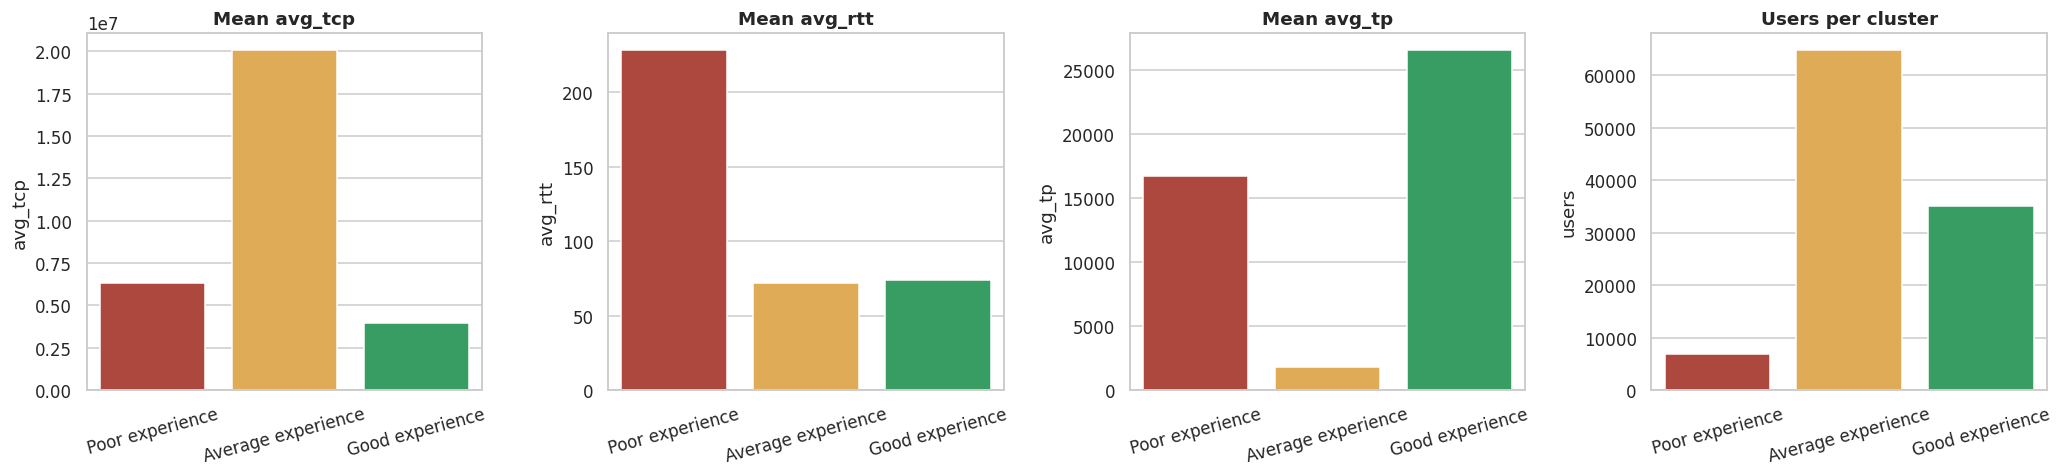

In [22]:
# 3.4 k-means (k=3) on experience metrics
ex_cols = ["avg_tcp", "avg_rtt", "avg_tp"]
sc_exp = StandardScaler()
exp_scaled = pd.DataFrame(sc_exp.fit_transform(exp_user[ex_cols]), columns=ex_cols)
km_exp = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(exp_scaled)
exp_user["exp_cluster"] = km_exp.labels_

# worst experience = highest (tcp + rtt) and lowest throughput on the standardised centroid
cent = pd.DataFrame(km_exp.cluster_centers_, columns=ex_cols)
badness = cent["avg_tcp"] + cent["avg_rtt"] - cent["avg_tp"]
worst = int(badness.idxmax()); best = int(badness.idxmin())
mid = [i for i in range(3) if i not in (worst, best)][0]
exp_names = {worst: "Poor experience", mid: "Average experience", best: "Good experience"}
exp_user["exp_segment"] = exp_user["exp_cluster"].map(exp_names)

prof = exp_user.groupby("exp_segment")[ex_cols].mean().round(1)
prof["users"] = exp_user["exp_segment"].value_counts()
print(prof)
prof.to_csv(f"{OUT_DIR}/experience_cluster_profile.csv")

order_e = ["Poor experience", "Average experience", "Good experience"]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, c in zip(axes[:3], ex_cols):
    sns.barplot(x=order_e, y=prof.loc[order_e, c], ax=ax, palette=["#c0392b", "#f5b041", "#27ae60"])
    ax.set_title(f"Mean {c}"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=15)
sns.barplot(x=order_e, y=prof.loc[order_e, "users"], ax=axes[3], palette=["#c0392b", "#f5b041", "#27ae60"])
axes[3].set_title("Users per cluster"); axes[3].tick_params(axis="x", rotation=15)
save_show("16_experience_clusters")

**Cluster descriptions** (numbers come from the profile table printed above)
* **Poor experience (~6% of users)** - very high latency (RTT about 228 ms, 3x the others) with
  moderate TCP retransmission: web pages / games feel laggy. Highest churn risk, fix cell/backhaul.
* **Average experience (~60%)** - normal RTT (~72 ms) but LOW throughput (~1.8 Mbps) and high
  retransmission volume: the network works but is slow. Biggest group = biggest upgrade opportunity.
* **Good experience (~33%)** - low retransmission, normal RTT and high throughput (~26 Mbps),
  mostly fixed-wireless routers and flagship phones.
Note: ~59% of TCP values were missing and were replaced by the mean (as the brief asks), which
creates a block of identical TCP values inside the "average" cluster.

# TASK 4 - SATISFACTION ANALYSIS

       engagement_score  experience_score  satisfaction_score
count        106856.000        106856.000          106856.000
mean              0.051             3.172               0.188
std               0.061             0.792               0.047
min               0.002             0.122               0.004
25%               0.017             2.578               0.151
50%               0.033             3.277               0.195
75%               0.058             3.802               0.222
max               1.642             8.951               0.690

Top 10 satisfied customers
  MSISDN/Number  engagement_score  experience_score  satisfaction_score
  3.362578e+10          1.641745          3.474331            0.689859
  3.361489e+10          1.435855          2.697103            0.583047
  3.362632e+10          1.390654          2.909955            0.581314
  3.365973e+10          1.220025          2.924426            0.530089
  3.367588e+10          1.201755          2.895562        

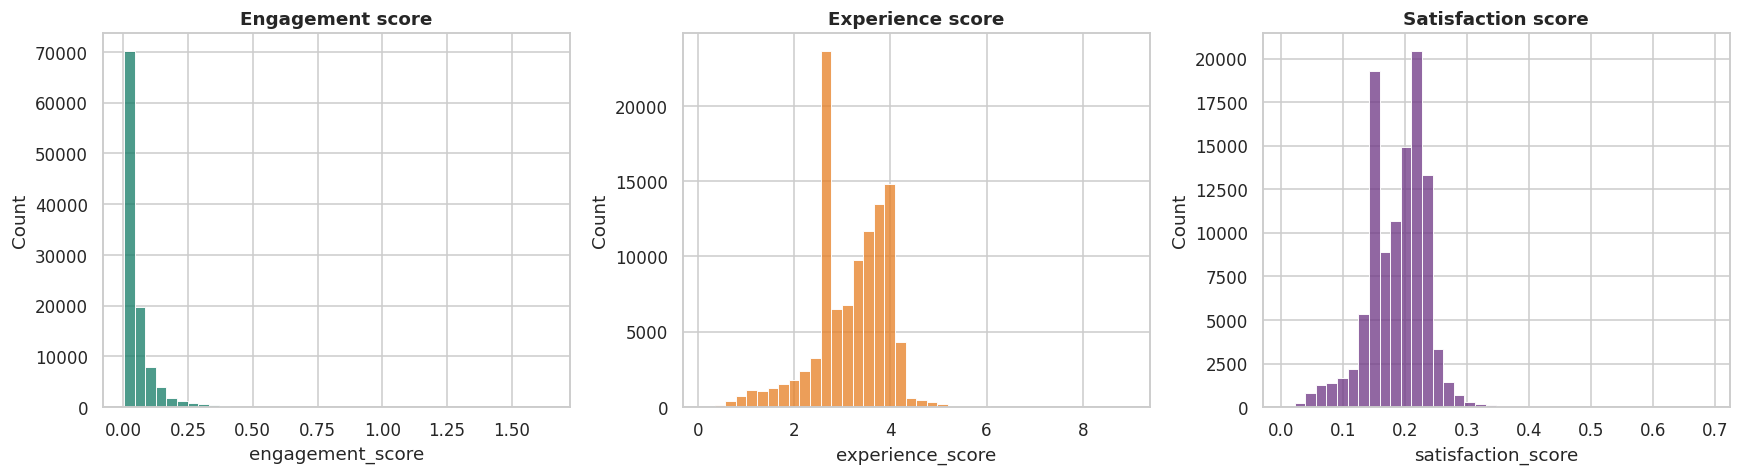

In [23]:
# 4.1 engagement score: distance to the LEAST engaged cluster (first clustering, normalised space)
less_eng_cluster = [k for k, v in names.items() if v == "Low engagement"][0]
c_low = km3.cluster_centers_[less_eng_cluster]
eng["engagement_score"] = np.linalg.norm(eng_norm.values - c_low, axis=1)

# experience score: distance to the WORST experience cluster (standardised space)
c_worst = km_exp.cluster_centers_[worst]
exp_user["experience_score"] = np.linalg.norm(exp_scaled.values - c_worst, axis=1)

final = eng[["MSISDN/Number", "sessions", "duration_ms", "traffic", "engagement_score"]].merge(
    exp_user[["MSISDN/Number", "avg_tcp", "avg_rtt", "avg_tp", "experience_score"]],
    on="MSISDN/Number", how="inner")

# The two distances live on different scales -> rescale both to 0-1 before averaging
final["engagement_score_scaled"] = MinMaxScaler().fit_transform(final[["engagement_score"]])
final["experience_score_scaled"] = MinMaxScaler().fit_transform(final[["experience_score"]])
# 4.2 satisfaction score = average of both
final["satisfaction_score"] = (final["engagement_score_scaled"] + final["experience_score_scaled"]) / 2
print(final[["engagement_score", "experience_score", "satisfaction_score"]].describe().round(3))

top10_sat = final.nlargest(10, "satisfaction_score")[
    ["MSISDN/Number", "engagement_score", "experience_score", "satisfaction_score"]]
print("\nTop 10 satisfied customers\n", top10_sat.to_string(index=False))
top10_sat.to_csv(f"{OUT_DIR}/top10_satisfied_customers.csv", index=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(final["engagement_score"], bins=40, ax=ax[0], color="#117a65"); ax[0].set_title("Engagement score")
sns.histplot(final["experience_score"], bins=40, ax=ax[1], color="#e67e22"); ax[1].set_title("Experience score")
sns.histplot(final["satisfaction_score"], bins=40, ax=ax[2], color="#6c3483"); ax[2].set_title("Satisfaction score")
save_show("17_scores_distribution")

                      R2    RMSE     MAE  train_sec
LinearRegression  0.7645  0.0230  0.0148     0.0142
RandomForest      0.9903  0.0047  0.0030    21.2832


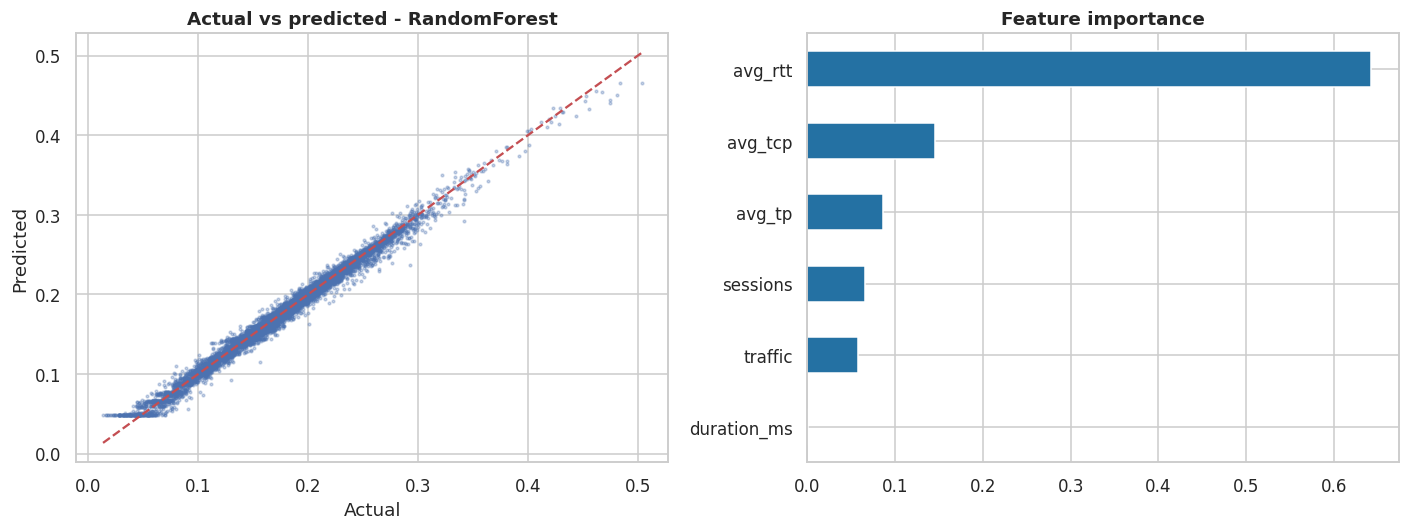

In [24]:
# 4.3 regression model to predict satisfaction score
feat = ["sessions", "duration_ms", "traffic", "avg_tcp", "avg_rtt", "avg_tp"]
Xtr, Xte, ytr, yte = train_test_split(final[feat], final["satisfaction_score"],
                                      test_size=0.2, random_state=RANDOM_STATE)
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1,
                                          random_state=RANDOM_STATE),
}
results = {}
for n, m in models.items():
    t0 = time.time(); m.fit(Xtr, ytr); pred = m.predict(Xte)
    results[n] = {"R2": r2_score(yte, pred), "RMSE": mean_squared_error(yte, pred) ** .5,
                  "MAE": mean_absolute_error(yte, pred), "train_sec": time.time() - t0}
res_df = pd.DataFrame(results).T
print(res_df.round(4))
res_df.to_csv(f"{OUT_DIR}/regression_results.csv")

best_name = res_df["R2"].idxmax()
best_model = models[best_name]
pred = best_model.predict(Xte)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(yte, pred, s=3, alpha=.3); ax[0].plot([yte.min(), yte.max()], [yte.min(), yte.max()], "r--")
ax[0].set_title(f"Actual vs predicted - {best_name}"); ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=feat).sort_values()
else:
    imp = pd.Series(np.abs(best_model.coef_), index=feat).sort_values()
imp.plot.barh(ax=ax[1], color="#2471a3"); ax[1].set_title("Feature importance")
save_show("18_regression")

             users  avg_satisfaction  avg_experience  avg_engagement
sat_cluster                                                         
0            60431            0.2185          3.7380          0.0474
1            46425            0.1472          2.4342          0.0558


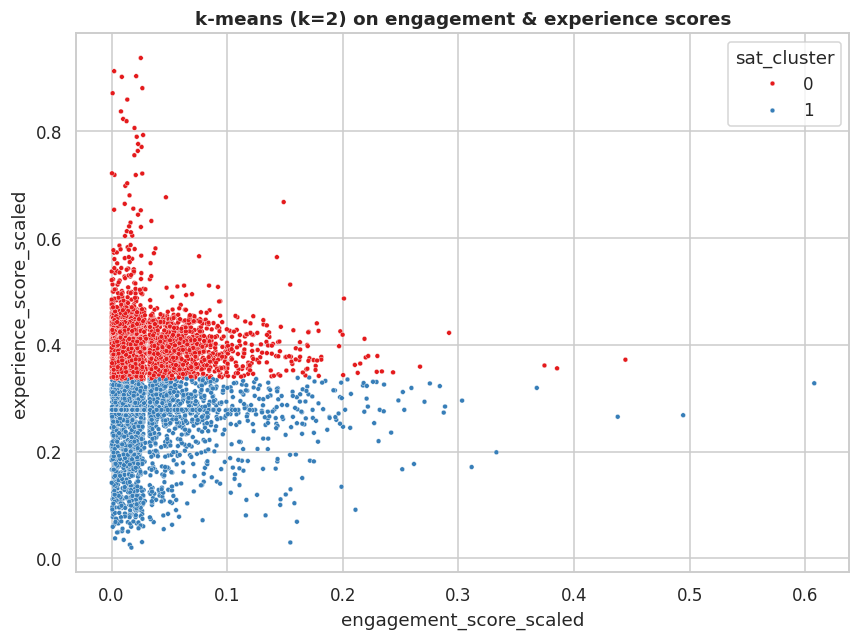

In [25]:
# 4.4 k-means (k=2) on engagement & experience score
sc2 = final[["engagement_score_scaled", "experience_score_scaled"]]
km2 = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(sc2)
final["sat_cluster"] = km2.labels_

# 4.5 average satisfaction & experience score per cluster
agg2 = final.groupby("sat_cluster").agg(
    users=("MSISDN/Number", "count"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_experience=("experience_score", "mean"),
    avg_engagement=("engagement_score", "mean")).round(4)
print(agg2)
agg2.to_csv(f"{OUT_DIR}/satisfaction_cluster_agg.csv")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=final.sample(8000, random_state=1), x="engagement_score_scaled",
                y="experience_score_scaled", hue="sat_cluster", palette="Set1", s=10)
plt.title("k-means (k=2) on engagement & experience scores")
save_show("19_sat_clusters")

[!] SQL Server export not possible here (ModuleNotFoundError: No module named 'pyodbc')
    Falling back to local SQLite so the query output can still be shown.
     MSISDN  engagement_score  experience_score  satisfaction_score  sat_cluster
33625779332          1.641745          3.474331            0.689859            0
33614892860          1.435855          2.697103            0.583047            1
33626320676          1.390654          2.909955            0.581314            1
33659725664          1.220025          2.924426            0.530089            1
33675877202          1.201755          2.895562            0.522882            1
33760536639          1.321646          2.058003            0.512021            1
33650133130          0.014008          8.951159            0.503522            0
33650652801          0.019713          8.579224            0.484200            0
33651586339          0.043963          8.394640            0.481144            0
33667511187          0.034664

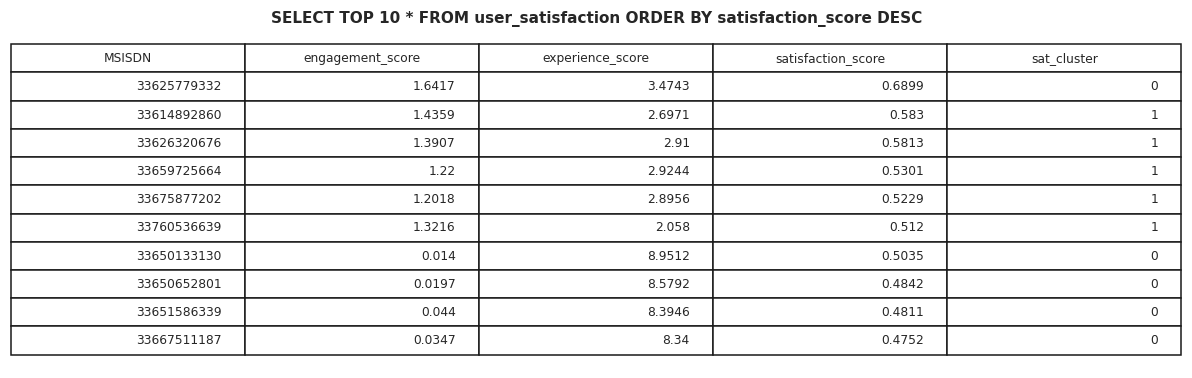

In [26]:
# 4.6 export to SQL Server  (.\SQLEXPRESS)  -----------------------------------
export_cols = ["MSISDN/Number", "engagement_score", "experience_score", "satisfaction_score", "sat_cluster"]
export_df = final[export_cols].rename(columns={"MSISDN/Number": "MSISDN"})
export_df["MSISDN"] = export_df["MSISDN"].astype("int64")
export_df.to_csv(f"{OUT_DIR}/final_user_scores.csv", index=False)       # always keep a CSV copy


def export_to_sql_server(df):
    """Create DB telecom_db on .\\SQLEXPRESS (Windows auth) and write the table."""
    import pyodbc
    from sqlalchemy import create_engine, text
    base = (f"DRIVER={{{SQL_DRIVER}}};SERVER={SQL_SERVER};"
            f"Trusted_Connection=yes;TrustServerCertificate=yes;")
    # create the database if it does not exist (autocommit needed for CREATE DATABASE)
    conn = pyodbc.connect(base + "DATABASE=master;", autocommit=True)
    conn.execute(f"IF DB_ID('{SQL_DATABASE}') IS NULL CREATE DATABASE [{SQL_DATABASE}]")
    conn.close()
    engine = create_engine("mssql+pyodbc:///?odbc_connect=" +
                           quote_plus(base + f"DATABASE={SQL_DATABASE};"), fast_executemany=True)
    df.to_sql(SQL_TABLE, engine, if_exists="replace", index=False, chunksize=5000)
    with engine.connect() as c:
        return pd.read_sql(text(f"SELECT TOP 10 * FROM {SQL_TABLE} ORDER BY satisfaction_score DESC"), c)


def export_to_sqlite_fallback(df):
    import sqlite3
    con = sqlite3.connect(f"{OUT_DIR}/telecom_db.sqlite")
    df.to_sql(SQL_TABLE, con, if_exists="replace", index=False)
    out = pd.read_sql(f"SELECT * FROM {SQL_TABLE} ORDER BY satisfaction_score DESC LIMIT 10", con)
    con.close()
    return out


try:
    sql_preview = export_to_sql_server(export_df)
    print(f"Exported to SQL Server {SQL_SERVER} -> {SQL_DATABASE}.dbo.{SQL_TABLE}")
except Exception as e:
    print(f"[!] SQL Server export not possible here ({type(e).__name__}: {str(e)[:120]})")
    print("    Falling back to local SQLite so the query output can still be shown.")
    sql_preview = export_to_sqlite_fallback(export_df)
print(sql_preview.to_string(index=False))

# "screenshot" of the SELECT output
fig, ax = plt.subplots(figsize=(11, 3.6)); ax.axis("off")
tbl = ax.table(cellText=sql_preview.round(4).astype(str).values, colLabels=sql_preview.columns, loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8); tbl.scale(1, 1.4)
ax.set_title(f"SELECT TOP 10 * FROM {SQL_TABLE} ORDER BY satisfaction_score DESC", fontsize=10)
save_show("20_sql_select_output")

                                                              0
run_id                                          20261001_111415
code_version                                       notebook-run
start_time                                  2026-10-01T11:14:15
end_time                                    2026-10-01T11:15:31
source                                     telcom_data__2_.xlsx
model                                     RandomForestRegressor
params        {"n_estimators": 100, "max_depth": 12, "featur...
R2                                                      0.99032
RMSE                                                    0.00466
MAE                                                     0.00304
artifacts                     outputs/satisfaction_model.joblib
MLflow not installed - tracking written to outputs/model_tracking.csv


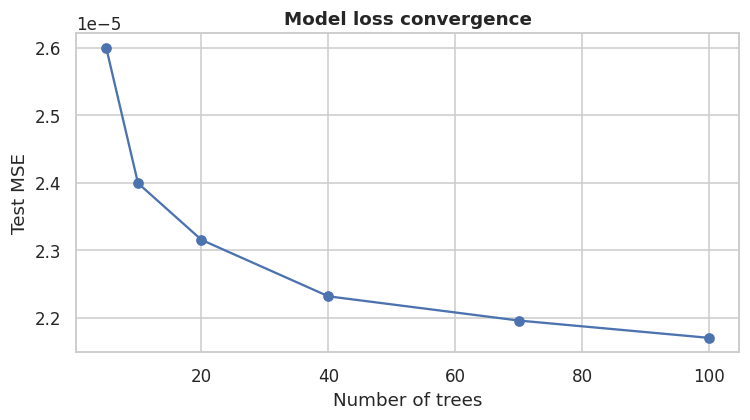

In [27]:
# 4.7 model deployment & tracking  -------------------------------------------
# Saves the model + a full run record (code version, start/end time, source, params, metrics,
# artifacts). Uses MLflow when installed, otherwise writes the same info to CSV/JSON.
def code_version():
    try:
        import subprocess
        return subprocess.check_output(["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL).decode().strip()
    except Exception:
        try:
            return "sha1:" + hashlib.sha1(open(__file__, "rb").read()).hexdigest()[:12]
        except NameError:
            return "notebook-run"


run_start = dt.datetime.now()
t_fit = time.time()
final_model = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
final_model.fit(Xtr, ytr)
loss_curve = []                                  # error as the forest grows (convergence)
for n in [5, 10, 20, 40, 70, 100]:
    rf = RandomForestRegressor(n_estimators=n, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE).fit(Xtr, ytr)
    loss_curve.append((n, mean_squared_error(yte, rf.predict(Xte))))
pred = final_model.predict(Xte)
metrics = {"R2": r2_score(yte, pred), "RMSE": mean_squared_error(yte, pred) ** .5,
           "MAE": mean_absolute_error(yte, pred)}
model_path = f"{OUT_DIR}/satisfaction_model.joblib"
joblib.dump(final_model, model_path)
run_end = dt.datetime.now()

record = {
    "run_id": run_start.strftime("%Y%m%d_%H%M%S"),
    "code_version": code_version(),
    "start_time": run_start.isoformat(timespec="seconds"),
    "end_time": run_end.isoformat(timespec="seconds"),
    "source": os.path.basename(DATA_FILE),
    "model": "RandomForestRegressor",
    "params": json.dumps({"n_estimators": 100, "max_depth": 12, "features": feat,
                          "test_size": 0.2, "random_state": RANDOM_STATE}),
    **{k: round(v, 5) for k, v in metrics.items()},
    "artifacts": model_path,
}
log_file = f"{OUT_DIR}/model_tracking.csv"
pd.DataFrame([record]).to_csv(log_file, mode="a", header=not os.path.exists(log_file), index=False)
pd.DataFrame(loss_curve, columns=["n_estimators", "mse"]).to_csv(f"{OUT_DIR}/loss_convergence.csv", index=False)
print(pd.DataFrame([record]).T)

try:                                              # optional: MLflow (pip install mlflow)
    import mlflow
    mlflow.set_experiment("tellco_satisfaction")
    with mlflow.start_run(run_name=record["run_id"]):
        mlflow.set_tag("code_version", record["code_version"]); mlflow.set_tag("source", record["source"])
        mlflow.log_params({"n_estimators": 100, "max_depth": 12, "test_size": 0.2})
        mlflow.log_metrics(metrics)
        for n, l in loss_curve:
            mlflow.log_metric("mse_vs_trees", l, step=n)
        mlflow.log_artifact(model_path); mlflow.log_artifact(log_file)
    print("MLflow run logged (open with: mlflow ui)")
except ImportError:
    print("MLflow not installed - tracking written to", log_file)

plt.figure(figsize=(7, 4))
plt.plot(*zip(*loss_curve), "o-"); plt.xlabel("Number of trees"); plt.ylabel("Test MSE")
plt.title("Model loss convergence")
save_show("21_loss_convergence")

# BUSINESS CONCLUSION & RECOMMENDATION
(see the PDF report / PPT for the full discussion)

In [28]:
total_users = final.shape[0]
share_poor = (exp_user["exp_segment"] == "Poor experience").mean() * 100
print(f"Users analysed: {total_users:,}")
print(f"Share of users with poor experience: {share_poor:.1f}%")
print("Total traffic (TB):", round(users_df['Total Data (Bytes)'].sum() / 1024 ** 4, 1))
print("Top apps (GB):", app_totals_gb.head(4).round(0).to_dict())

Users analysed: 106,856
Share of users with poor experience: 6.4%
Total traffic (TB): 67.2
Top apps (GB): {'Gaming': 59687.0, 'Other': 59562.0, 'Youtube': 3141.0, 'Netflix': 3139.0}
